#  Kaggle HBAAC 2026 — Demand Forecasting (v4)

A global LightGBM model featuring target-lag features, rolling window aggregates, exponential weighted averages, Vietnamese holiday proximity encodings, SKU-level metrics, and profit-weighted post-processing.

-
-
-

#
#
 

 
C
e
l
l
 
1
 
—
 
L
i
b
r
a
r
i
e
s
 
&
 
C
o
n
s
t
a
n
t
s

In [46]:
i
m
p
o
r
t
 
n
u
m
p
y
 
a
s
 
n
p

i
m
p
o
r
t
 
p
a
n
d
a
s
 
a
s
 
p
d

i
m
p
o
r
t
 
l
i
g
h
t
g
b
m
 
a
s
 
l
g
b

i
m
p
o
r
t
 
w
a
r
n
i
n
g
s

f
r
o
m
 
p
a
t
h
l
i
b
 
i
m
p
o
r
t
 
P
a
t
h


w
a
r
n
i
n
g
s
.
f
i
l
t
e
r
w
a
r
n
i
n
g
s
(
'
i
g
n
o
r
e
'
)

p
d
.
s
e
t
_
o
p
t
i
o
n
(
'
d
i
s
p
l
a
y
.
m
a
x
_
c
o
l
u
m
n
s
'
,
 
5
0
)

p
d
.
s
e
t
_
o
p
t
i
o
n
(
'
d
i
s
p
l
a
y
.
f
l
o
a
t
_
f
o
r
m
a
t
'
,
 
'
{
:
.
4
f
}
'
.
f
o
r
m
a
t
)


I
N
P
U
T
_
D
I
R
 
 
=
 
P
a
t
h
(
'
/
k
a
g
g
l
e
/
i
n
p
u
t
/
c
o
m
p
e
t
i
t
i
o
n
s
/
h
b
a
a
c
-
r
o
u
n
d
2
'
)

O
U
T
P
U
T
_
D
I
R
 
=
 
P
a
t
h
(
'
/
k
a
g
g
l
e
/
w
o
r
k
i
n
g
'
)

T
R
A
I
N
_
P
A
T
H
 
 
=
 
I
N
P
U
T
_
D
I
R
 
/
 
'
t
r
a
i
n
.
c
s
v
'

S
A
M
P
L
E
_
P
A
T
H
 
=
 
I
N
P
U
T
_
D
I
R
 
/
 
'
s
a
m
p
l
e
_
s
u
b
m
i
s
s
i
o
n
.
c
s
v
'


T
R
A
I
N
_
S
T
A
R
T
 
=
 
p
d
.
T
i
m
e
s
t
a
m
p
(
'
2
0
2
0
-
1
1
-
1
7
'
)

T
R
A
I
N
_
E
N
D
 
 
 
=
 
p
d
.
T
i
m
e
s
t
a
m
p
(
'
2
0
2
5
-
0
9
-
0
5
'
)

V
A
L
_
S
T
A
R
T
 
 
 
=
 
p
d
.
T
i
m
e
s
t
a
m
p
(
'
2
0
2
5
-
0
9
-
0
6
'
)

V
A
L
_
E
N
D
 
 
 
 
 
=
 
p
d
.
T
i
m
e
s
t
a
m
p
(
'
2
0
2
5
-
1
0
-
0
3
'
)

E
V
A
L
_
S
T
A
R
T
 
 
=
 
p
d
.
T
i
m
e
s
t
a
m
p
(
'
2
0
2
5
-
1
0
-
0
4
'
)

E
V
A
L
_
E
N
D
 
 
 
 
=
 
p
d
.
T
i
m
e
s
t
a
m
p
(
'
2
0
2
5
-
1
0
-
3
1
'
)

S
P
L
I
T
_
D
A
T
E
 
 
=
 
p
d
.
T
i
m
e
s
t
a
m
p
(
'
2
0
2
5
-
0
7
-
1
2
'
)

H
O
R
I
Z
O
N
 
 
 
 
 
=
 
5
6

S
E
E
D
 
 
 
 
 
 
 
 
=
 
4
2

p
r
i
n
t
(
'
L
i
b
r
a
r
i
e
s
 
l
o
a
d
e
d
 
\
u
2
7
1
3
'
)

Libraries loaded ✓


-
-
-

#
#
 

️
 
C
e
l
l
 
2
 
—
 
L
o
a
d
 
&
 
P
a
r
s
e
 
R
a
w
 
D
a
t
a

In [47]:
d
e
f
 
p
a
r
s
e
_
v
n
d
(
s
e
r
i
e
s
:
 
p
d
.
S
e
r
i
e
s
)
 
-
>
 
p
d
.
S
e
r
i
e
s
:

 
 
 
 
"
"
"
P
a
r
s
e
 
V
i
e
t
n
a
m
e
s
e
 
d
e
c
i
m
a
l
-
c
o
m
m
a
 
n
u
m
b
e
r
 
s
t
r
i
n
g
s
 
t
o
 
f
l
o
a
t
.
"
"
"

 
 
 
 
r
e
t
u
r
n
 
(

 
 
 
 
 
 
 
 
s
e
r
i
e
s
.
a
s
t
y
p
e
(
s
t
r
)
.
s
t
r
.
s
t
r
i
p
(
)

 
 
 
 
 
 
 
 
.
s
t
r
.
r
e
p
l
a
c
e
(
'
.
'
,
 
'
'
,
 
r
e
g
e
x
=
F
a
l
s
e
)

 
 
 
 
 
 
 
 
.
s
t
r
.
r
e
p
l
a
c
e
(
'
,
'
,
 
'
.
'
,
 
r
e
g
e
x
=
F
a
l
s
e
)

 
 
 
 
 
 
 
 
.
r
e
p
l
a
c
e
(
{
'
n
a
n
'
:
 
n
p
.
n
a
n
,
 
'
'
:
 
n
p
.
n
a
n
}
)

 
 
 
 
 
 
 
 
.
a
s
t
y
p
e
(
f
l
o
a
t
)

 
 
 
 
)


p
r
i
n
t
(
'
R
e
a
d
i
n
g
 
t
r
a
i
n
.
c
s
v
 
.
.
.
'
)

r
a
w
 
=
 
p
d
.
r
e
a
d
_
c
s
v
(

 
 
 
 
T
R
A
I
N
_
P
A
T
H
,

 
 
 
 
d
t
y
p
e
=
{
'
S
t
t
'
:
 
'
s
t
r
'
,
 
'
I
t
e
m
C
o
d
e
'
:
 
'
s
t
r
'
,
 
'
U
n
i
t
P
r
i
c
e
'
:
 
'
s
t
r
'
,
 
'
U
n
i
t
 
C
o
s
t
'
:
 
'
s
t
r
'
}
,

 
 
 
 
p
a
r
s
e
_
d
a
t
e
s
=
[
'
D
a
t
e
'
]
,

 
 
 
 
l
o
w
_
m
e
m
o
r
y
=
F
a
l
s
e

)

r
a
w
[
'
Q
u
a
n
t
i
t
y
'
]
 
 
 
 
=
 
p
d
.
t
o
_
n
u
m
e
r
i
c
(
r
a
w
[
'
Q
u
a
n
t
i
t
y
'
]
,
 
 
 
 
e
r
r
o
r
s
=
'
c
o
e
r
c
e
'
)
.
f
i
l
l
n
a
(
0
)
.
a
s
t
y
p
e
(
'
i
n
t
3
2
'
)

r
a
w
[
'
S
a
l
e
s
A
m
o
u
n
t
'
]
 
=
 
p
d
.
t
o
_
n
u
m
e
r
i
c
(
r
a
w
[
'
S
a
l
e
s
A
m
o
u
n
t
'
]
,
 
e
r
r
o
r
s
=
'
c
o
e
r
c
e
'
)
.
f
i
l
l
n
a
(
0
)
.
a
s
t
y
p
e
(
'
i
n
t
6
4
'
)

r
a
w
[
'
C
o
s
t
 
A
m
o
u
n
t
'
]
 
=
 
p
d
.
t
o
_
n
u
m
e
r
i
c
(
r
a
w
[
'
C
o
s
t
 
A
m
o
u
n
t
'
]
,
 
e
r
r
o
r
s
=
'
c
o
e
r
c
e
'
)
.
f
i
l
l
n
a
(
0
)
.
a
s
t
y
p
e
(
'
i
n
t
6
4
'
)

r
a
w
[
'
U
n
i
t
P
r
i
c
e
'
]
 
=
 
p
a
r
s
e
_
v
n
d
(
r
a
w
[
'
U
n
i
t
P
r
i
c
e
'
]
)

r
a
w
[
'
U
n
i
t
 
C
o
s
t
'
]
 
=
 
p
a
r
s
e
_
v
n
d
(
r
a
w
[
'
U
n
i
t
 
C
o
s
t
'
]
)

r
a
w
[
'
I
t
e
m
C
o
d
e
'
]
 
=
 
r
a
w
[
'
I
t
e
m
C
o
d
e
'
]
.
a
s
t
y
p
e
(
'
c
a
t
e
g
o
r
y
'
)


p
r
i
n
t
(
f
'
R
a
w
 
r
o
w
s
 
 
 
 
 
 
:
 
{
l
e
n
(
r
a
w
)
:
,
}
'
)

p
r
i
n
t
(
f
'
S
K
U
s
 
 
 
 
 
 
 
 
 
 
:
 
{
r
a
w
[
"
I
t
e
m
C
o
d
e
"
]
.
n
u
n
i
q
u
e
(
)
:
,
}
'
)

p
r
i
n
t
(
f
'
D
a
t
e
 
r
a
n
g
e
 
 
 
 
:
 
{
r
a
w
[
"
D
a
t
e
"
]
.
m
i
n
(
)
.
d
a
t
e
(
)
}
 
\
u
2
1
9
2
 
{
r
a
w
[
"
D
a
t
e
"
]
.
m
a
x
(
)
.
d
a
t
e
(
)
}
'
)

p
r
i
n
t
(
f
'
R
e
t
u
r
n
s
 
r
o
w
s
 
 
:
 
{
(
r
a
w
[
"
Q
u
a
n
t
i
t
y
"
]
 
<
 
0
)
.
s
u
m
(
)
:
,
}
 
 
(
{
(
r
a
w
[
"
Q
u
a
n
t
i
t
y
"
]
 
<
 
0
)
.
m
e
a
n
(
)
*
1
0
0
:
.
1
f
}
%
)
'
)

Reading train.csv ...
Raw rows      : 711,980
SKUs          : 15,972
Date range    : 2020-11-17 → 2025-09-05
Returns rows  : 37,434  (5.3%)


-
-
-

#
#
 

 
C
e
l
l
 
3
 
—
 
P
e
r
-
S
K
U
 
P
r
o
f
i
t
 
W
e
i
g
h
t
s

In [48]:
r
a
w
[
'
P
r
o
f
i
t
'
]
 
=
 
r
a
w
[
'
S
a
l
e
s
A
m
o
u
n
t
'
]
.
a
s
t
y
p
e
(
f
l
o
a
t
)
 
-
 
r
a
w
[
'
C
o
s
t
 
A
m
o
u
n
t
'
]
.
a
s
t
y
p
e
(
f
l
o
a
t
)

s
k
u
_
p
r
o
f
i
t
 
=
 
(

 
 
 
 
r
a
w
.
g
r
o
u
p
b
y
(
'
I
t
e
m
C
o
d
e
'
,
 
o
b
s
e
r
v
e
d
=
T
r
u
e
)
[
'
P
r
o
f
i
t
'
]

 
 
 
 
 
 
 
.
s
u
m
(
)
.
r
e
s
e
t
_
i
n
d
e
x
(
)
.
r
e
n
a
m
e
(
c
o
l
u
m
n
s
=
{
'
P
r
o
f
i
t
'
:
 
'
t
o
t
a
l
_
p
r
o
f
i
t
'
}
)

)

s
k
u
_
p
r
o
f
i
t
[
'
t
o
t
a
l
_
p
r
o
f
i
t
'
]
 
=
 
s
k
u
_
p
r
o
f
i
t
[
'
t
o
t
a
l
_
p
r
o
f
i
t
'
]
.
c
l
i
p
(
l
o
w
e
r
=
0
)

t
o
t
a
l
 
=
 
s
k
u
_
p
r
o
f
i
t
[
'
t
o
t
a
l
_
p
r
o
f
i
t
'
]
.
s
u
m
(
)

s
k
u
_
p
r
o
f
i
t
[
'
w
e
i
g
h
t
'
]
 
=
 
s
k
u
_
p
r
o
f
i
t
[
'
t
o
t
a
l
_
p
r
o
f
i
t
'
]
 
/
 
t
o
t
a
l
 
i
f
 
t
o
t
a
l
 
>
 
0
 
e
l
s
e
 
0
.
0

p
r
i
n
t
(
f
'
S
K
U
s
 
w
i
t
h
 
p
o
s
i
t
i
v
e
 
p
r
o
f
i
t
 
:
 
{
(
s
k
u
_
p
r
o
f
i
t
[
"
t
o
t
a
l
_
p
r
o
f
i
t
"
]
 
>
 
0
)
.
s
u
m
(
)
:
,
}
'
)

p
r
i
n
t
(
f
'
T
o
t
a
l
 
p
r
o
f
i
t
 
(
V
N
D
)
 
 
 
 
 
 
 
 
:
 
{
t
o
t
a
l
:
,
.
0
f
}
'
)

s
k
u
_
p
r
o
f
i
t
.
n
l
a
r
g
e
s
t
(
1
0
,
 
'
w
e
i
g
h
t
'
)
[
[
'
I
t
e
m
C
o
d
e
'
,
 
'
t
o
t
a
l
_
p
r
o
f
i
t
'
,
 
'
w
e
i
g
h
t
'
]
]

SKUs with positive profit : 14,139
Total profit (VND)        : 180,034,123,945


,ItemCode,total_profit,weight
2,SKU-00003,16700681088.0000,0.0928
1,SKU-00002,8012686409.0000,0.0445
9197,SKU-09458,2668406627.0000,0.0148
4,SKU-00005,2243340437.0000,0.0125
8354,SKU-08589,1287111640.0000,0.0071
12229,SKU-12534,1215803793.0000,0.0068
9492,SKU-09760,1200524689.0000,0.0067
12230,SKU-12537,1106799793.0000,0.0061
315,SKU-00324,979471964.0000,0.0054
13993,SKU-14323,967927091.0000,0.0054


-
-
-

#
#
 

 
C
e
l
l
 
4
 
—
 
H
a
n
d
l
e
 
R
e
t
u
r
n
s
 
&
 
A
g
g
r
e
g
a
t
e
 
D
a
i
l
y

In [49]:
d
a
i
l
y
 
=
 
(

 
 
 
 
r
a
w
.
g
r
o
u
p
b
y
(
[
'
I
t
e
m
C
o
d
e
'
,
 
'
D
a
t
e
'
]
,
 
o
b
s
e
r
v
e
d
=
T
r
u
e
)

 
 
 
 
.
a
g
g
(

 
 
 
 
 
 
 
 
Q
u
a
n
t
i
t
y
=
(
'
Q
u
a
n
t
i
t
y
'
,
 
'
s
u
m
'
)
,

 
 
 
 
 
 
 
 
S
a
l
e
s
A
m
o
u
n
t
=
(
'
S
a
l
e
s
A
m
o
u
n
t
'
,
 
'
s
u
m
'
)
,

 
 
 
 
 
 
 
 
C
o
s
t
A
m
o
u
n
t
=
(
'
C
o
s
t
 
A
m
o
u
n
t
'
,
 
'
s
u
m
'
)
,

 
 
 
 
)

 
 
 
 
.
r
e
s
e
t
_
i
n
d
e
x
(
)

)

d
a
i
l
y
[
'
Q
u
a
n
t
i
t
y
'
]
 
=
 
d
a
i
l
y
[
'
Q
u
a
n
t
i
t
y
'
]
.
c
l
i
p
(
l
o
w
e
r
=
0
)

p
r
i
n
t
(
f
'
D
a
i
l
y
 
g
r
a
i
n
 
r
o
w
s
:
 
{
l
e
n
(
d
a
i
l
y
)
:
,
}
'
)

Daily grain rows: 507,050


-
-
-

#
#
 

 
C
e
l
l
 
5
 
—
 
R
e
i
n
d
e
x
 
t
o
 
F
u
l
l
 
D
a
i
l
y
 
C
a
l
e
n
d
a
r

In [50]:
a
l
l
_
d
a
t
e
s
 
=
 
p
d
.
d
a
t
e
_
r
a
n
g
e
(
T
R
A
I
N
_
S
T
A
R
T
,
 
T
R
A
I
N
_
E
N
D
,
 
f
r
e
q
=
'
D
'
)

a
l
l
_
s
k
u
s
 
 
=
 
d
a
i
l
y
[
'
I
t
e
m
C
o
d
e
'
]
.
c
a
t
.
c
a
t
e
g
o
r
i
e
s
 
i
f
 
h
a
s
a
t
t
r
(
d
a
i
l
y
[
'
I
t
e
m
C
o
d
e
'
]
,
 
'
c
a
t
'
)
 
\

 
 
 
 
 
 
 
 
 
 
 
 
e
l
s
e
 
d
a
i
l
y
[
'
I
t
e
m
C
o
d
e
'
]
.
u
n
i
q
u
e
(
)

f
u
l
l
_
i
d
x
 
=
 
p
d
.
M
u
l
t
i
I
n
d
e
x
.
f
r
o
m
_
p
r
o
d
u
c
t
(
[
a
l
l
_
s
k
u
s
,
 
a
l
l
_
d
a
t
e
s
]
,
 
n
a
m
e
s
=
[
'
I
t
e
m
C
o
d
e
'
,
 
'
D
a
t
e
'
]
)

p
r
i
n
t
(
f
'
F
u
l
l
 
g
r
i
d
:
 
{
l
e
n
(
f
u
l
l
_
i
d
x
)
:
,
}
 
r
o
w
s
 
(
{
l
e
n
(
a
l
l
_
s
k
u
s
)
:
,
}
 
S
K
U
s
 
\
u
0
0
d
7
 
{
l
e
n
(
a
l
l
_
d
a
t
e
s
)
:
,
}
 
d
a
y
s
)
'
)


d
a
i
l
y
 
=
 
(

 
 
 
 
d
a
i
l
y
.
s
e
t
_
i
n
d
e
x
(
[
'
I
t
e
m
C
o
d
e
'
,
 
'
D
a
t
e
'
]
)

 
 
 
 
.
r
e
i
n
d
e
x
(
f
u
l
l
_
i
d
x
,
 
f
i
l
l
_
v
a
l
u
e
=
0
)

 
 
 
 
.
r
e
s
e
t
_
i
n
d
e
x
(
)

)

d
a
i
l
y
[
'
I
t
e
m
C
o
d
e
'
]
 
=
 
d
a
i
l
y
[
'
I
t
e
m
C
o
d
e
'
]
.
a
s
t
y
p
e
(
'
c
a
t
e
g
o
r
y
'
)

d
a
i
l
y
[
'
Q
u
a
n
t
i
t
y
'
]
 
=
 
d
a
i
l
y
[
'
Q
u
a
n
t
i
t
y
'
]
.
a
s
t
y
p
e
(
'
f
l
o
a
t
3
2
'
)

p
r
i
n
t
(
f
'
A
f
t
e
r
 
r
e
i
n
d
e
x
:
 
{
l
e
n
(
d
a
i
l
y
)
:
,
}
 
r
o
w
s
'
)

Full grid: 28,014,888 rows (15,972 SKUs × 1,754 days)
After reindex: 28,014,888 rows


-
-
-

#
#
 

️
 
C
e
l
l
 
6
 
—
 
V
i
e
t
n
a
m
e
s
e
 
P
u
b
l
i
c
 
H
o
l
i
d
a
y
s
 
(
E
x
t
e
n
d
e
d
)

In [51]:
d
e
f
 
g
e
t
_
v
i
e
t
n
a
m
e
s
e
_
h
o
l
i
d
a
y
s
(
s
t
a
r
t
_
y
e
a
r
=
2
0
2
0
,
 
e
n
d
_
y
e
a
r
=
2
0
2
6
)
:

 
 
 
 
"
"
"
R
e
t
u
r
n
s
 
(
D
a
t
e
t
i
m
e
I
n
d
e
x
,
 
d
i
c
t
 
o
f
 
T
e
t
 
D
a
y
1
 
p
e
r
 
y
e
a
r
)
.
"
"
"

 
 
 
 
h
o
l
i
d
a
y
s
 
=
 
[
]

 
 
 
 
f
i
x
e
d
 
=
 
[
'
0
1
-
0
1
'
,
 
'
0
4
-
3
0
'
,
 
'
0
5
-
0
1
'
,
 
'
0
9
-
0
2
'
]

 
 
 
 
l
u
n
a
r
_
n
e
w
_
y
e
a
r
_
d
a
y
1
 
=
 
{

 
 
 
 
 
 
 
 
2
0
2
0
:
 
'
2
0
2
0
-
0
1
-
2
5
'
,
 
2
0
2
1
:
 
'
2
0
2
1
-
0
2
-
1
2
'
,
 
2
0
2
2
:
 
'
2
0
2
2
-
0
2
-
0
1
'
,

 
 
 
 
 
 
 
 
2
0
2
3
:
 
'
2
0
2
3
-
0
1
-
2
2
'
,
 
2
0
2
4
:
 
'
2
0
2
4
-
0
2
-
1
0
'
,
 
2
0
2
5
:
 
'
2
0
2
5
-
0
1
-
2
9
'
,

 
 
 
 
 
 
 
 
2
0
2
6
:
 
'
2
0
2
6
-
0
2
-
1
7
'
,

 
 
 
 
}

 
 
 
 
h
u
n
g
_
k
i
n
g
s
 
=
 
{

 
 
 
 
 
 
 
 
2
0
2
0
:
 
'
2
0
2
0
-
0
4
-
0
2
'
,
 
2
0
2
1
:
 
'
2
0
2
1
-
0
4
-
2
1
'
,
 
2
0
2
2
:
 
'
2
0
2
2
-
0
4
-
1
0
'
,

 
 
 
 
 
 
 
 
2
0
2
3
:
 
'
2
0
2
3
-
0
4
-
2
9
'
,
 
2
0
2
4
:
 
'
2
0
2
4
-
0
4
-
1
8
'
,
 
2
0
2
5
:
 
'
2
0
2
5
-
0
4
-
0
7
'
,

 
 
 
 
 
 
 
 
2
0
2
6
:
 
'
2
0
2
6
-
0
4
-
2
6
'
,

 
 
 
 
}

 
 
 
 
t
e
t
_
d
a
y
1
_
d
a
t
e
s
 
=
 
{
}

 
 
 
 
f
o
r
 
y
e
a
r
 
i
n
 
r
a
n
g
e
(
s
t
a
r
t
_
y
e
a
r
,
 
e
n
d
_
y
e
a
r
 
+
 
1
)
:

 
 
 
 
 
 
 
 
f
o
r
 
m
m
d
d
 
i
n
 
f
i
x
e
d
:

 
 
 
 
 
 
 
 
 
 
 
 
h
o
l
i
d
a
y
s
.
a
p
p
e
n
d
(
p
d
.
T
i
m
e
s
t
a
m
p
(
f
'
{
y
e
a
r
}
-
{
m
m
d
d
}
'
)
)

 
 
 
 
 
 
 
 
i
f
 
y
e
a
r
 
i
n
 
l
u
n
a
r
_
n
e
w
_
y
e
a
r
_
d
a
y
1
:

 
 
 
 
 
 
 
 
 
 
 
 
d
1
 
=
 
p
d
.
T
i
m
e
s
t
a
m
p
(
l
u
n
a
r
_
n
e
w
_
y
e
a
r
_
d
a
y
1
[
y
e
a
r
]
)

 
 
 
 
 
 
 
 
 
 
 
 
t
e
t
_
d
a
y
1
_
d
a
t
e
s
[
y
e
a
r
]
 
=
 
d
1

 
 
 
 
 
 
 
 
 
 
 
 
s
h
i
f
t
_
d
a
y
s
 
=
 
(
d
1
.
d
a
y
o
f
w
e
e
k
 
+
 
2
)
 
%
 
7

 
 
 
 
 
 
 
 
 
 
 
 
s
t
a
r
t
_
d
a
t
e
 
=
 
d
1
 
-
 
p
d
.
T
i
m
e
d
e
l
t
a
(
d
a
y
s
=
s
h
i
f
t
_
d
a
y
s
)

 
 
 
 
 
 
 
 
 
 
 
 
e
n
d
_
d
a
t
e
 
 
 
=
 
s
t
a
r
t
_
d
a
t
e
 
+
 
p
d
.
T
i
m
e
d
e
l
t
a
(
d
a
y
s
=
8
)

 
 
 
 
 
 
 
 
 
 
 
 
h
o
l
i
d
a
y
s
.
e
x
t
e
n
d
(
p
d
.
d
a
t
e
_
r
a
n
g
e
(
s
t
a
r
t
_
d
a
t
e
,
 
e
n
d
_
d
a
t
e
,
 
f
r
e
q
=
'
D
'
)
.
t
o
l
i
s
t
(
)
)

 
 
 
 
 
 
 
 
i
f
 
y
e
a
r
 
i
n
 
h
u
n
g
_
k
i
n
g
s
:

 
 
 
 
 
 
 
 
 
 
 
 
h
o
l
i
d
a
y
s
.
a
p
p
e
n
d
(
p
d
.
T
i
m
e
s
t
a
m
p
(
h
u
n
g
_
k
i
n
g
s
[
y
e
a
r
]
)
)

 
 
 
 
r
e
t
u
r
n
 
p
d
.
D
a
t
e
t
i
m
e
I
n
d
e
x
(
s
o
r
t
e
d
(
s
e
t
(
h
o
l
i
d
a
y
s
)
)
)
,
 
t
e
t
_
d
a
y
1
_
d
a
t
e
s


V
N
_
H
O
L
I
D
A
Y
S
,
 
T
E
T
_
D
A
Y
1
_
D
I
C
T
 
=
 
g
e
t
_
v
i
e
t
n
a
m
e
s
e
_
h
o
l
i
d
a
y
s
(
2
0
2
0
,
 
2
0
2
6
)

T
E
T
_
D
A
Y
1
_
L
I
S
T
 
=
 
s
o
r
t
e
d
(
T
E
T
_
D
A
Y
1
_
D
I
C
T
.
v
a
l
u
e
s
(
)
)

p
r
i
n
t
(
f
'
T
o
t
a
l
 
h
o
l
i
d
a
y
 
d
a
t
e
s
 
:
 
{
l
e
n
(
V
N
_
H
O
L
I
D
A
Y
S
)
}
'
)

p
r
i
n
t
(
f
'
T
e
t
 
D
a
y
 
1
 
d
a
t
e
s
 
 
 
 
 
:
 
{
[
s
t
r
(
d
.
d
a
t
e
(
)
)
 
f
o
r
 
d
 
i
n
 
T
E
T
_
D
A
Y
1
_
L
I
S
T
]
}
'
)

Total holiday dates : 98
Tet Day 1 dates     : ['2020-01-25', '2021-02-12', '2022-02-01', '2023-01-22', '2024-02-10', '2025-01-29', '2026-02-17']


-
-
-

#
#
 

️
 
C
e
l
l
 
7
 
—
 
F
e
a
t
u
r
e
 
E
n
g
i
n
e
e
r
i
n
g
 
(
v
4
 
E
n
h
a
n
c
e
d
)

In [52]:
def build_features(df, vn_holidays, tet_day1_list):
    """Build comprehensive features for demand forecasting, including lags, rolling statistics, exponential moving averages, holiday proximity, SKU-level stats, and pricing indicators."""
    df = df.sort_values(['ItemCode', 'Date']).copy()
    
    # 1. Basic Time Features
    df['dayofweek']     = df['Date'].dt.dayofweek.astype('int8')
    df['day']           = df['Date'].dt.day.astype('int8')
    df['month']         = df['Date'].dt.month.astype('int8')
    df['year']          = df['Date'].dt.year.astype('int16')
    df['quarter']       = df['Date'].dt.quarter.astype('int8')
    df['weekofyear']    = df['Date'].dt.isocalendar().week.astype('int8')
    df['days_in_month'] = df['Date'].dt.days_in_month.astype('int8')
    df['is_weekend']    = (df['dayofweek'] >= 5).astype('int8')
    df['is_month_start']= (df['day'] <= 3).astype('int8')
    df['is_month_end']  = (df['day'] >= 28).astype('int8')
    df['is_holiday']    = df['Date'].isin(vn_holidays).astype('int8')
    
    # 2. Holiday Windows (Extended: pre-14d, post-7d)
    holiday_dates_sorted = sorted(vn_holidays)
    unique_dates = df['Date'].unique()
    
    next_hol_map   = {}
    since_hol_map  = {}
    pre14_map      = {}
    pre7_map       = {}
    post7_map      = {}
    post3_map      = {}
    days_to_tet_map    = {}
    days_since_tet_map = {}
    is_tet_season_map  = {}
    
    for d in unique_dates:
        future_hols     = [h for h in holiday_dates_sorted if h > d]
        past_hols       = [h for h in holiday_dates_sorted if h < d]
        days_to_next    = (future_hols[0] - d).days if future_hols else 365
        days_since_last = (d - past_hols[-1]).days  if past_hols  else 365
        
        next_hol_map[d]  = days_to_next
        since_hol_map[d] = days_since_last
        pre14_map[d]  = 1 if (0 < days_to_next  <= 14) else 0
        pre7_map[d]   = 1 if (0 < days_to_next  <= 7)  else 0
        post7_map[d]  = 1 if (0 < days_since_last <= 7) else 0
        post3_map[d]  = 1 if (0 < days_since_last <= 3) else 0
        
        future_tet = [t for t in tet_day1_list if t > d]
        past_tet   = [t for t in tet_day1_list if t <= d]
        d_to_tet   = (future_tet[0] - d).days if future_tet else 365
        d_from_tet = (d - past_tet[-1]).days   if past_tet   else 365
        days_to_tet_map[d]    = min(d_to_tet, 365)
        days_since_tet_map[d] = min(d_from_tet, 365)
        is_tet_season_map[d]  = 1 if (d_to_tet <= 30 or d_from_tet <= 30) else 0
    
    df['days_to_next_holiday']    = df['Date'].map(next_hol_map).astype('int16')
    df['days_since_last_holiday'] = df['Date'].map(since_hol_map).astype('int16')
    df['is_pre_holiday_14d']      = df['Date'].map(pre14_map).astype('int8')
    df['is_pre_holiday_7d']       = df['Date'].map(pre7_map).astype('int8')
    df['is_post_holiday_7d']      = df['Date'].map(post7_map).astype('int8')
    df['is_post_holiday_3d']      = df['Date'].map(post3_map).astype('int8')
    df['days_to_tet']             = df['Date'].map(days_to_tet_map).astype('int16')
    df['days_since_tet']          = df['Date'].map(days_since_tet_map).astype('int16')
    df['is_tet_season']           = df['Date'].map(is_tet_season_map).astype('int8')
    
    # 3. Lag + Rolling Features (all lags >= 56 days for leak-free 56-day horizon)
    grp = df.groupby('ItemCode', observed=True)['Quantity']
    
    # Core lags + yearly seasonality lags
    for lag in [56, 63, 70, 84, 91, 357, 364, 371]:
        df[f'lag_{lag}'] = grp.shift(lag).astype('float32')
    
    # Rolling stats from lag-56 (leak-free)
    lag56 = grp.shift(56)
    for window in [7, 14, 28, 56]:
        df[f'roll_mean_{window}'] = lag56.transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        ).astype('float32')
        df[f'roll_std_{window}'] = lag56.transform(
            lambda x: x.rolling(window, min_periods=1).std()
        ).fillna(0).astype('float32')
    
    # EWM: captures trend with recency bias
    for span in [28, 56]:
        df[f'ewm_mean_{span}'] = lag56.transform(
            lambda x: x.ewm(span=span, min_periods=1).mean()
        ).astype('float32')
    
    # 4. SKU-Level Statistics
    n_days = df['Date'].nunique()
    df['sku_sales_freq']  = grp.transform(lambda x: (x > 0).sum() / n_days).astype('float32')
    df['sku_active_days'] = grp.transform(lambda x: (x > 0).sum()).astype('int16')
    df['sku_median_qty']  = grp.transform('median').astype('float32')
    sku_mean = grp.transform('mean')
    sku_std  = grp.transform('std').fillna(0)
    df['sku_cv'] = (sku_std / (sku_mean + 1e-6)).clip(upper=10).astype('float32')
    
    # 5. Croston: Days-since-last-sale (from lag_56 perspective)
    def days_since_last_sale_transform(series):
        is_zero = (series == 0).astype(int)
        streak = is_zero.groupby((is_zero != is_zero.shift()).cumsum()).cumsum()
        return streak
    df['lag_56_days_since_sale'] = (
        df.groupby('ItemCode', observed=True)['lag_56']
          .transform(days_since_last_sale_transform)
          .astype('int16')
    )
    
    # 6. Price & Margin Features
    if 'SalesAmount' in df.columns:
        df['implied_price'] = np.where(df['Quantity'] > 0, df['SalesAmount'] / df['Quantity'], np.nan)
        df['implied_price'] = df.groupby('ItemCode', observed=True)['implied_price'].ffill()
        sku_median_price = df.groupby('ItemCode', observed=True)['implied_price'].transform('median')
        df['implied_price'] = df['implied_price'].fillna(sku_median_price).fillna(0)
        
        df['implied_cost'] = np.where(df['Quantity'] > 0, df['CostAmount'] / df['Quantity'], np.nan)
        df['implied_cost'] = df.groupby('ItemCode', observed=True)['implied_cost'].ffill()
        sku_median_cost = df.groupby('ItemCode', observed=True)['implied_cost'].transform('median')
        df['implied_cost'] = df['implied_cost'].fillna(sku_median_cost).fillna(0)
        
        df['margin_rate'] = np.where(
            df['implied_price'] > 0,
            (df['implied_price'] - df['implied_cost']) / df['implied_price'],
            0.0
        ).astype('float32')
        df['price_norm'] = np.where(
            sku_median_price > 0, df['implied_price'] / sku_median_price, 1.0
        ).astype('float32')
        
        grp_p = df.groupby('ItemCode', observed=True)
        df['lag_56_price_norm']  = grp_p['price_norm'].shift(56).astype('float32')
        df['lag_56_is_discount'] = (df['lag_56_price_norm'] < 0.95).astype('int8')
        df['lag_56_margin_rate'] = grp_p['margin_rate'].shift(56).astype('float32')
        df.drop(columns=['implied_price', 'implied_cost', 'price_norm', 'margin_rate'], inplace=True)
    
    return df

print('Building v4 enhanced features (may take ~2-3 min) ...')
daily = build_features(daily, VN_HOLIDAYS, TET_DAY1_LIST)
print(f'Total columns after feature engineering: {len(daily.columns)}')
print('Columns:', daily.columns.tolist())


Building v4 enhanced features (may take ~2-3 min) ...
Total columns after feature engineering: 51
Columns: ['ItemCode', 'Date', 'Quantity', 'SalesAmount', 'CostAmount', 'dayofweek', 'day', 'month', 'year', 'quarter', 'weekofyear', 'days_in_month', 'is_weekend', 'is_month_start', 'is_month_end', 'is_holiday', 'days_to_next_holiday', 'days_since_last_holiday', 'is_pre_holiday_14d', 'is_pre_holiday_7d', 'is_post_holiday_7d', 'is_post_holiday_3d', 'days_to_tet', 'days_since_tet', 'is_tet_season', 'lag_56', 'lag_63', 'lag_70', 'lag_84', 'lag_91', 'lag_357', 'lag_364', 'lag_371', 'roll_mean_7', 'roll_std_7', 'roll_mean_14', 'roll_std_14', 'roll_mean_28', 'roll_std_28', 'roll_mean_56', 'roll_std_56', 'ewm_mean_28', 'ewm_mean_56', 'sku_sales_freq', 'sku_active_days', 'sku_median_qty', 'sku_cv', 'lag_56_days_since_sale', 'lag_56_price_norm', 'lag_56_is_discount', 'lag_56_margin_rate']


-
-
-

#
#
 

 
C
e
l
l
 
8
 
—
 
W
R
M
S
S
E
 
M
e
t
r
i
c

In [53]:
d
e
f
 
c
o
m
p
u
t
e
_
w
r
m
s
s
e
(
y
_
t
r
u
e
,
 
y
_
p
r
e
d
,
 
t
r
a
i
n
_
s
e
r
i
e
s
,
 
w
e
i
g
h
t
s
)
:

 
 
 
 
"
"
"

 
 
 
 
W
R
M
S
S
E
 
=
 
s
u
m
(
w
_
i
 
*
 
R
M
S
S
E
_
i
)

 
 
 
 
R
M
S
S
E
_
i
 
=
 
s
q
r
t
(
M
S
E
_
f
o
r
e
c
a
s
t
_
i
 
/
 
M
S
E
_
n
a
i
v
e
_
i
)

 
 
 
 
M
S
E
_
n
a
i
v
e
_
i
 
=
 
m
e
a
n
(
(
t
r
a
i
n
[
t
]
 
-
 
t
r
a
i
n
[
t
-
1
]
)
^
2
)

 
 
 
 
"
"
"

 
 
 
 
e
p
s
 
 
 
 
 
 
 
 
 
 
=
 
1
e
-
9

 
 
 
 
n
a
i
v
e
_
e
r
r
o
r
s
 
=
 
n
p
.
d
i
f
f
(
t
r
a
i
n
_
s
e
r
i
e
s
,
 
a
x
i
s
=
1
)
 
*
*
 
2

 
 
 
 
d
e
n
o
m
 
 
 
 
 
 
 
 
=
 
n
a
i
v
e
_
e
r
r
o
r
s
.
m
e
a
n
(
a
x
i
s
=
1
)

 
 
 
 
m
s
e
_
f
o
r
e
c
a
s
t
 
=
 
(
(
y
_
t
r
u
e
 
-
 
y
_
p
r
e
d
)
 
*
*
 
2
)
.
m
e
a
n
(
a
x
i
s
=
1
)

 
 
 
 
r
m
s
s
e
 
 
 
 
 
 
 
 
=
 
n
p
.
s
q
r
t
(
m
s
e
_
f
o
r
e
c
a
s
t
 
/
 
(
d
e
n
o
m
 
+
 
e
p
s
)
)

 
 
 
 
r
e
t
u
r
n
 
f
l
o
a
t
(
n
p
.
s
u
m
(
w
e
i
g
h
t
s
 
*
 
r
m
s
s
e
)
)


p
r
i
n
t
(
'
W
R
M
S
S
E
 
m
e
t
r
i
c
 
f
u
n
c
t
i
o
n
 
d
e
f
i
n
e
d
 
\
u
2
7
1
3
'
)

WRMSSE metric function defined ✓


-
-
-

#
#
 

️
 
C
e
l
l
 
9
 
—
 
T
r
a
i
n
/
V
a
l
 
S
p
l
i
t
 
&
 
S
a
m
p
l
e
 
W
e
i
g
h
t
s

In [54]:
E
X
C
L
U
D
E
_
C
O
L
S
 
=
 
[
'
D
a
t
e
'
,
 
'
Q
u
a
n
t
i
t
y
'
,
 
'
S
a
l
e
s
A
m
o
u
n
t
'
,
 
'
C
o
s
t
A
m
o
u
n
t
'
]

F
E
A
T
U
R
E
_
C
O
L
S
 
=
 
[
c
 
f
o
r
 
c
 
i
n
 
d
a
i
l
y
.
c
o
l
u
m
n
s
 
i
f
 
c
 
n
o
t
 
i
n
 
E
X
C
L
U
D
E
_
C
O
L
S
]

p
r
i
n
t
(
f
'
F
e
a
t
u
r
e
s
 
(
{
l
e
n
(
F
E
A
T
U
R
E
_
C
O
L
S
)
}
)
:
 
{
F
E
A
T
U
R
E
_
C
O
L
S
}
'
)


t
r
a
i
n
_
d
f
 
=
 
d
a
i
l
y
[
d
a
i
l
y
[
'
D
a
t
e
'
]
 
<
 
 
S
P
L
I
T
_
D
A
T
E
]
.
c
o
p
y
(
)

v
a
l
_
d
f
 
 
 
=
 
d
a
i
l
y
[
(
d
a
i
l
y
[
'
D
a
t
e
'
]
 
>
=
 
S
P
L
I
T
_
D
A
T
E
)
 
&
 
(
d
a
i
l
y
[
'
D
a
t
e
'
]
 
<
=
 
T
R
A
I
N
_
E
N
D
)
]
.
c
o
p
y
(
)


#
 
C
r
o
s
s
 
f
e
a
t
u
r
e
s
 
(
l
e
a
k
-
f
r
e
e
:
 
c
o
m
p
u
t
e
d
 
f
r
o
m
 
t
r
a
i
n
 
o
n
l
y
)

p
r
i
n
t
(
'
C
o
m
p
u
t
i
n
g
 
l
e
a
k
-
f
r
e
e
 
c
r
o
s
s
 
f
e
a
t
u
r
e
s
 
.
.
.
'
)

s
k
u
_
m
a
p
 
 
 
=
 
t
r
a
i
n
_
d
f
.
g
r
o
u
p
b
y
(
'
I
t
e
m
C
o
d
e
'
,
 
o
b
s
e
r
v
e
d
=
T
r
u
e
)
[
'
Q
u
a
n
t
i
t
y
'
]
.
m
e
a
n
(
)
.
t
o
_
d
i
c
t
(
)

d
o
w
_
m
a
p
 
 
 
=
 
t
r
a
i
n
_
d
f
.
g
r
o
u
p
b
y
(
[
'
I
t
e
m
C
o
d
e
'
,
 
'
d
a
y
o
f
w
e
e
k
'
]
,
 
o
b
s
e
r
v
e
d
=
T
r
u
e
)
[
'
Q
u
a
n
t
i
t
y
'
]
.
m
e
a
n
(
)
.
t
o
_
d
i
c
t
(
)

m
o
n
t
h
_
m
a
p
 
=
 
t
r
a
i
n
_
d
f
.
g
r
o
u
p
b
y
(
[
'
I
t
e
m
C
o
d
e
'
,
 
'
m
o
n
t
h
'
]
,
 
o
b
s
e
r
v
e
d
=
T
r
u
e
)
[
'
Q
u
a
n
t
i
t
y
'
]
.
m
e
a
n
(
)
.
t
o
_
d
i
c
t
(
)


d
e
f
 
m
a
p
_
c
r
o
s
s
_
f
e
a
t
u
r
e
s
(
d
f
)
:

 
 
 
 
d
f
 
=
 
d
f
.
c
o
p
y
(
)

 
 
 
 
d
f
[
'
s
k
u
_
m
e
a
n
_
q
t
y
'
]
 
=
 
d
f
[
'
I
t
e
m
C
o
d
e
'
]
.
m
a
p
(
s
k
u
_
m
a
p
)
.
f
i
l
l
n
a
(
0
)
.
a
s
t
y
p
e
(
'
f
l
o
a
t
3
2
'
)

 
 
 
 
d
k
 
=
 
p
d
.
M
u
l
t
i
I
n
d
e
x
.
f
r
o
m
_
a
r
r
a
y
s
(
[
d
f
[
'
I
t
e
m
C
o
d
e
'
]
,
 
d
f
[
'
d
a
y
o
f
w
e
e
k
'
]
]
)

 
 
 
 
d
f
[
'
s
k
u
_
d
o
w
_
m
e
a
n
'
]
 
=
 
d
k
.
m
a
p
(
d
o
w
_
m
a
p
)
.
f
i
l
l
n
a
(
0
)
.
a
s
t
y
p
e
(
'
f
l
o
a
t
3
2
'
)

 
 
 
 
m
k
 
=
 
p
d
.
M
u
l
t
i
I
n
d
e
x
.
f
r
o
m
_
a
r
r
a
y
s
(
[
d
f
[
'
I
t
e
m
C
o
d
e
'
]
,
 
d
f
[
'
m
o
n
t
h
'
]
]
)

 
 
 
 
d
f
[
'
s
k
u
_
m
o
n
t
h
_
m
e
a
n
'
]
 
=
 
m
k
.
m
a
p
(
m
o
n
t
h
_
m
a
p
)
.
f
i
l
l
n
a
(
0
)
.
a
s
t
y
p
e
(
'
f
l
o
a
t
3
2
'
)

 
 
 
 
r
e
t
u
r
n
 
d
f


d
a
i
l
y
 
 
 
 
=
 
m
a
p
_
c
r
o
s
s
_
f
e
a
t
u
r
e
s
(
d
a
i
l
y
)

t
r
a
i
n
_
d
f
 
=
 
m
a
p
_
c
r
o
s
s
_
f
e
a
t
u
r
e
s
(
t
r
a
i
n
_
d
f
)

v
a
l
_
d
f
 
 
 
=
 
m
a
p
_
c
r
o
s
s
_
f
e
a
t
u
r
e
s
(
v
a
l
_
d
f
)


i
f
 
'
s
k
u
_
m
e
a
n
_
q
t
y
'
 
n
o
t
 
i
n
 
F
E
A
T
U
R
E
_
C
O
L
S
:

 
 
 
 
F
E
A
T
U
R
E
_
C
O
L
S
.
e
x
t
e
n
d
(
[
'
s
k
u
_
m
e
a
n
_
q
t
y
'
,
 
'
s
k
u
_
d
o
w
_
m
e
a
n
'
,
 
'
s
k
u
_
m
o
n
t
h
_
m
e
a
n
'
]
)


#
 
P
r
o
f
i
t
 
w
e
i
g
h
t
s
 
(
u
s
i
n
g
 
o
n
l
y
 
p
r
e
-
s
p
l
i
t
 
t
r
a
i
n
i
n
g
 
d
a
t
a
)

t
r
a
i
n
_
r
a
w
 
=
 
r
a
w
[
r
a
w
[
'
D
a
t
e
'
]
 
<
 
S
P
L
I
T
_
D
A
T
E
]
.
c
o
p
y
(
)

t
r
a
i
n
_
r
a
w
[
'
P
r
o
f
i
t
'
]
 
=
 
t
r
a
i
n
_
r
a
w
[
'
S
a
l
e
s
A
m
o
u
n
t
'
]
.
a
s
t
y
p
e
(
f
l
o
a
t
)
 
-
 
t
r
a
i
n
_
r
a
w
[
'
C
o
s
t
 
A
m
o
u
n
t
'
]
.
a
s
t
y
p
e
(
f
l
o
a
t
)

s
k
u
_
p
r
o
f
i
t
_
v
a
l
 
=
 
(

 
 
 
 
t
r
a
i
n
_
r
a
w
.
g
r
o
u
p
b
y
(
'
I
t
e
m
C
o
d
e
'
,
 
o
b
s
e
r
v
e
d
=
T
r
u
e
)
[
'
P
r
o
f
i
t
'
]

 
 
 
 
 
 
 
.
s
u
m
(
)
.
r
e
s
e
t
_
i
n
d
e
x
(
)
.
r
e
n
a
m
e
(
c
o
l
u
m
n
s
=
{
'
P
r
o
f
i
t
'
:
 
'
t
o
t
a
l
_
p
r
o
f
i
t
'
}
)

)

s
k
u
_
p
r
o
f
i
t
_
v
a
l
[
'
t
o
t
a
l
_
p
r
o
f
i
t
'
]
 
=
 
s
k
u
_
p
r
o
f
i
t
_
v
a
l
[
'
t
o
t
a
l
_
p
r
o
f
i
t
'
]
.
c
l
i
p
(
l
o
w
e
r
=
0
)

t
o
t
a
l
_
p
 
=
 
s
k
u
_
p
r
o
f
i
t
_
v
a
l
[
'
t
o
t
a
l
_
p
r
o
f
i
t
'
]
.
s
u
m
(
)

s
k
u
_
p
r
o
f
i
t
_
v
a
l
[
'
w
e
i
g
h
t
'
]
 
=
 
s
k
u
_
p
r
o
f
i
t
_
v
a
l
[
'
t
o
t
a
l
_
p
r
o
f
i
t
'
]
 
/
 
t
o
t
a
l
_
p
 
i
f
 
t
o
t
a
l
_
p
 
>
 
0
 
e
l
s
e
 
0
.
0


#
 
v
4
 
S
a
m
p
l
e
 
W
e
i
g
h
t
s
:
 
p
r
o
f
i
t
^
0
.
7
 
/
 
s
q
r
t
(
d
e
n
o
m
)
 
—
 
c
a
p
p
e
d
 
a
t
 
5
0
x
 
m
e
d
i
a
n

t
r
a
i
n
_
p
i
v
o
t
_
d
e
n
o
m
 
=
 
t
r
a
i
n
_
d
f
.
p
i
v
o
t
(
i
n
d
e
x
=
'
I
t
e
m
C
o
d
e
'
,
 
c
o
l
u
m
n
s
=
'
D
a
t
e
'
,
 
v
a
l
u
e
s
=
'
Q
u
a
n
t
i
t
y
'
)

n
a
i
v
e
_
e
r
r
o
r
s
_
w
 
 
 
 
=
 
n
p
.
d
i
f
f
(
t
r
a
i
n
_
p
i
v
o
t
_
d
e
n
o
m
.
v
a
l
u
e
s
,
 
a
x
i
s
=
1
)
 
*
*
 
2

d
e
n
o
m
_
v
a
l
u
e
s
_
w
 
 
 
 
=
 
n
a
i
v
e
_
e
r
r
o
r
s
_
w
.
m
e
a
n
(
a
x
i
s
=
1
)

d
e
n
o
m
_
d
f
_
w
 
 
 
 
 
 
 
 
=
 
p
d
.
D
a
t
a
F
r
a
m
e
(
{
'
I
t
e
m
C
o
d
e
'
:
 
t
r
a
i
n
_
p
i
v
o
t
_
d
e
n
o
m
.
i
n
d
e
x
,
 
'
d
e
n
o
m
'
:
 
d
e
n
o
m
_
v
a
l
u
e
s
_
w
}
)


s
k
u
_
s
t
a
t
s
_
v
a
l
 
=
 
s
k
u
_
p
r
o
f
i
t
_
v
a
l
.
m
e
r
g
e
(
d
e
n
o
m
_
d
f
_
w
,
 
o
n
=
'
I
t
e
m
C
o
d
e
'
,
 
h
o
w
=
'
l
e
f
t
'
)

f
o
r
 
c
o
l
 
i
n
 
[
'
w
e
i
g
h
t
'
,
 
'
d
e
n
o
m
'
,
 
'
t
o
t
a
l
_
p
r
o
f
i
t
'
]
:

 
 
 
 
s
k
u
_
s
t
a
t
s
_
v
a
l
[
c
o
l
]
 
=
 
s
k
u
_
s
t
a
t
s
_
v
a
l
[
c
o
l
]
.
f
i
l
l
n
a
(
0
.
0
)


e
p
s
_
w
 
=
 
0
.
0
1

#
 
S
o
f
t
e
r
 
e
x
p
o
n
e
n
t
 
(
0
.
7
)
 
g
i
v
e
s
 
s
p
a
r
s
e
 
S
K
U
s
 
m
o
r
e
 
r
e
p
r
e
s
e
n
t
a
t
i
o
n
 
t
h
a
n
 
p
u
r
e
 
p
r
o
f
i
t
 
w
e
i
g
h
t
i
n
g

s
k
u
_
s
t
a
t
s
_
v
a
l
[
'
s
a
m
p
l
e
_
w
e
i
g
h
t
'
]
 
=
 
(

 
 
 
 
s
k
u
_
s
t
a
t
s
_
v
a
l
[
'
t
o
t
a
l
_
p
r
o
f
i
t
'
]
 
*
*
 
0
.
7
 
/
 
n
p
.
s
q
r
t
(
s
k
u
_
s
t
a
t
s
_
v
a
l
[
'
d
e
n
o
m
'
]
 
+
 
e
p
s
_
w
)

)

p
o
s
_
m
a
s
k
 
 
 
 
 
=
 
s
k
u
_
s
t
a
t
s
_
v
a
l
[
'
s
a
m
p
l
e
_
w
e
i
g
h
t
'
]
 
>
 
0

m
e
d
i
a
n
_
s
w
 
 
 
 
=
 
s
k
u
_
s
t
a
t
s
_
v
a
l
.
l
o
c
[
p
o
s
_
m
a
s
k
,
 
'
s
a
m
p
l
e
_
w
e
i
g
h
t
'
]
.
m
e
d
i
a
n
(
)

s
k
u
_
s
t
a
t
s
_
v
a
l
[
'
s
a
m
p
l
e
_
w
e
i
g
h
t
'
]
 
=
 
s
k
u
_
s
t
a
t
s
_
v
a
l
[
'
s
a
m
p
l
e
_
w
e
i
g
h
t
'
]
.
c
l
i
p
(
u
p
p
e
r
=
5
0
 
*
 
m
e
d
i
a
n
_
s
w
)


w
e
i
g
h
t
_
m
a
p
 
 
 
 
=
 
s
k
u
_
s
t
a
t
s
_
v
a
l
.
s
e
t
_
i
n
d
e
x
(
'
I
t
e
m
C
o
d
e
'
)
[
'
s
a
m
p
l
e
_
w
e
i
g
h
t
'
]
.
t
o
_
d
i
c
t
(
)

t
r
a
i
n
_
w
e
i
g
h
t
s
 
=
 
t
r
a
i
n
_
d
f
[
'
I
t
e
m
C
o
d
e
'
]
.
m
a
p
(
w
e
i
g
h
t
_
m
a
p
)
.
f
i
l
l
n
a
(
0
.
0
)
.
v
a
l
u
e
s

i
f
 
t
r
a
i
n
_
w
e
i
g
h
t
s
.
s
u
m
(
)
 
>
 
0
:

 
 
 
 
t
r
a
i
n
_
w
e
i
g
h
t
s
 
=
 
t
r
a
i
n
_
w
e
i
g
h
t
s
 
/
 
t
r
a
i
n
_
w
e
i
g
h
t
s
.
m
e
a
n
(
)


#
 
T
a
r
g
e
t
:
 
s
q
u
a
r
e
 
r
o
o
t
 
t
r
a
n
s
f
o
r
m
 
(
s
t
a
b
i
l
i
z
e
s
 
P
o
i
s
s
o
n
-
l
i
k
e
 
v
a
r
i
a
n
c
e
)

X
_
t
r
a
i
n
,
 
y
_
t
r
a
i
n
 
=
 
t
r
a
i
n
_
d
f
[
F
E
A
T
U
R
E
_
C
O
L
S
]
,
 
n
p
.
s
q
r
t
(
t
r
a
i
n
_
d
f
[
'
Q
u
a
n
t
i
t
y
'
]
)

X
_
v
a
l
,
 
 
 
y
_
v
a
l
 
 
 
=
 
v
a
l
_
d
f
[
F
E
A
T
U
R
E
_
C
O
L
S
]
,
 
 
 
n
p
.
s
q
r
t
(
v
a
l
_
d
f
[
'
Q
u
a
n
t
i
t
y
'
]
)


p
r
i
n
t
(
f
'
T
r
a
i
n
:
 
{
l
e
n
(
t
r
a
i
n
_
d
f
)
:
,
}
 
r
o
w
s
 
|
 
{
t
r
a
i
n
_
d
f
[
"
D
a
t
e
"
]
.
m
i
n
(
)
.
d
a
t
e
(
)
}
 
-
>
 
{
t
r
a
i
n
_
d
f
[
"
D
a
t
e
"
]
.
m
a
x
(
)
.
d
a
t
e
(
)
}
'
)

p
r
i
n
t
(
f
'
V
a
l
 
 
:
 
{
l
e
n
(
v
a
l
_
d
f
)
:
,
}
 
r
o
w
s
 
|
 
{
v
a
l
_
d
f
[
"
D
a
t
e
"
]
.
m
i
n
(
)
.
d
a
t
e
(
)
}
 
-
>
 
{
v
a
l
_
d
f
[
"
D
a
t
e
"
]
.
m
a
x
(
)
.
d
a
t
e
(
)
}
'
)

p
r
i
n
t
(
f
'
N
o
n
-
z
e
r
o
 
s
a
m
p
l
e
 
w
e
i
g
h
t
s
:
 
{
(
t
r
a
i
n
_
w
e
i
g
h
t
s
 
>
 
0
)
.
s
u
m
(
)
:
,
}
 
/
 
{
l
e
n
(
t
r
a
i
n
_
w
e
i
g
h
t
s
)
:
,
}
'
)



Features (47): ['ItemCode', 'dayofweek', 'day', 'month', 'year', 'quarter', 'weekofyear', 'days_in_month', 'is_weekend', 'is_month_start', 'is_month_end', 'is_holiday', 'days_to_next_holiday', 'days_since_last_holiday', 'is_pre_holiday_14d', 'is_pre_holiday_7d', 'is_post_holiday_7d', 'is_post_holiday_3d', 'days_to_tet', 'days_since_tet', 'is_tet_season', 'lag_56', 'lag_63', 'lag_70', 'lag_84', 'lag_91', 'lag_357', 'lag_364', 'lag_371', 'roll_mean_7', 'roll_std_7', 'roll_mean_14', 'roll_std_14', 'roll_mean_28', 'roll_std_28', 'roll_mean_56', 'roll_std_56', 'ewm_mean_28', 'ewm_mean_56', 'sku_sales_freq', 'sku_active_days', 'sku_median_qty', 'sku_cv', 'lag_56_days_since_sale', 'lag_56_price_norm', 'lag_56_is_discount', 'lag_56_margin_rate']
Computing leak-free cross features ...
Train: 27,120,456 rows | 2020-11-17 -> 2025-07-11
Val  : 894,432 rows | 2025-07-12 -> 2025-09-05
Non-zero sample weights: 23,398,440 / 27,120,456


-
-
-

#
#
 

 
C
e
l
l
 
1
0
 
—
 
L
i
g
h
t
G
B
M
 
T
r
a
i
n
i
n
g
 
(
v
4
 
T
u
n
e
d
 
P
a
r
a
m
s
)

In [55]:
l
g
b
_
t
r
a
i
n
 
=
 
l
g
b
.
D
a
t
a
s
e
t
(

 
 
 
 
X
_
t
r
a
i
n
,
 
l
a
b
e
l
=
y
_
t
r
a
i
n
,
 
w
e
i
g
h
t
=
t
r
a
i
n
_
w
e
i
g
h
t
s
,

 
 
 
 
c
a
t
e
g
o
r
i
c
a
l
_
f
e
a
t
u
r
e
=
[
'
I
t
e
m
C
o
d
e
'
]
,
 
f
r
e
e
_
r
a
w
_
d
a
t
a
=
F
a
l
s
e

)

l
g
b
_
v
a
l
 
=
 
l
g
b
.
D
a
t
a
s
e
t
(

 
 
 
 
X
_
v
a
l
,
 
l
a
b
e
l
=
y
_
v
a
l
,

 
 
 
 
c
a
t
e
g
o
r
i
c
a
l
_
f
e
a
t
u
r
e
=
[
'
I
t
e
m
C
o
d
e
'
]
,
 
r
e
f
e
r
e
n
c
e
=
l
g
b
_
t
r
a
i
n
,
 
f
r
e
e
_
r
a
w
_
d
a
t
a
=
F
a
l
s
e

)


#
 
v
4
 
H
y
p
e
r
p
a
r
a
m
e
t
e
r
s
:

#
 
-
 
n
u
m
_
l
e
a
v
e
s
=
2
5
5
 
(
w
a
s
 
1
2
7
)
:
 
m
o
r
e
 
m
o
d
e
l
 
c
a
p
a
c
i
t
y
 
f
o
r
 
c
o
m
p
l
e
x
 
s
e
a
s
o
n
a
l
i
t
y

#
 
-
 
l
r
=
0
.
0
5
 
(
w
a
s
 
0
.
0
3
)
:
 
f
a
s
t
e
r
 
c
o
n
v
e
r
g
e
n
c
e
,
 
m
o
r
e
 
d
i
v
e
r
s
i
t
y
 
w
i
t
h
 
5
0
0
0
 
r
o
u
n
d
s

#
 
-
 
e
a
r
l
y
_
s
t
o
p
=
1
0
0
 
(
w
a
s
 
5
0
)
:
 
l
e
s
s
 
a
g
g
r
e
s
s
i
v
e
 
s
t
o
p
p
i
n
g
,
 
b
e
t
t
e
r
 
g
e
n
e
r
a
l
i
z
a
t
i
o
n

#
 
-
 
m
i
n
_
c
h
i
l
d
_
s
a
m
p
l
e
s
=
3
0
 
(
w
a
s
 
2
0
)
:
 
m
o
r
e
 
c
o
n
s
e
r
v
a
t
i
v
e
 
s
p
l
i
t
s

#
 
-
 
l
a
m
b
d
a
_
l
2
=
0
.
5
 
(
w
a
s
 
0
.
1
)
:
 
s
t
r
o
n
g
e
r
 
L
2
 
r
e
g
u
l
a
r
i
z
a
t
i
o
n
 
a
g
a
i
n
s
t
 
o
v
e
r
f
i
t
t
i
n
g

#
 
-
 
p
a
t
h
_
s
m
o
o
t
h
=
0
.
5
 
(
n
e
w
)
:
 
s
m
o
o
t
h
 
l
e
a
f
 
v
a
l
u
e
 
e
s
t
i
m
a
t
i
o
n
 
f
o
r
 
s
p
a
r
s
e
 
p
a
t
h
s

p
a
r
a
m
s
 
=
 
{

 
 
 
 
'
o
b
j
e
c
t
i
v
e
'
:
 
 
 
 
 
 
 
 
 
'
r
e
g
r
e
s
s
i
o
n
'
,

 
 
 
 
'
m
e
t
r
i
c
'
:
 
 
 
 
 
 
 
 
 
 
 
 
'
r
m
s
e
'
,

 
 
 
 
'
l
e
a
r
n
i
n
g
_
r
a
t
e
'
:
 
 
 
 
 
0
.
0
5
,

 
 
 
 
'
n
u
m
_
l
e
a
v
e
s
'
:
 
 
 
 
 
 
 
 
2
5
5
,

 
 
 
 
'
m
a
x
_
d
e
p
t
h
'
:
 
 
 
 
 
 
 
 
 
-
1
,

 
 
 
 
'
m
i
n
_
c
h
i
l
d
_
s
a
m
p
l
e
s
'
:
 
3
0
,

 
 
 
 
'
f
e
a
t
u
r
e
_
f
r
a
c
t
i
o
n
'
:
 
 
0
.
7
5
,

 
 
 
 
'
b
a
g
g
i
n
g
_
f
r
a
c
t
i
o
n
'
:
 
 
0
.
8
5
,

 
 
 
 
'
b
a
g
g
i
n
g
_
f
r
e
q
'
:
 
 
 
 
 
 
1
,

 
 
 
 
'
l
a
m
b
d
a
_
l
1
'
:
 
 
 
 
 
 
 
 
 
0
.
0
5
,

 
 
 
 
'
l
a
m
b
d
a
_
l
2
'
:
 
 
 
 
 
 
 
 
 
0
.
5
,

 
 
 
 
'
p
a
t
h
_
s
m
o
o
t
h
'
:
 
 
 
 
 
 
 
0
.
5
,

 
 
 
 
'
v
e
r
b
o
s
e
'
:
 
 
 
 
 
 
 
 
 
 
 
-
1
,

 
 
 
 
'
s
e
e
d
'
:
 
 
 
 
 
 
 
 
 
 
 
 
 
 
S
E
E
D
,

 
 
 
 
'
n
_
j
o
b
s
'
:
 
 
 
 
 
 
 
 
 
 
 
 
-
1
,

}

c
a
l
l
b
a
c
k
s
 
=
 
[
l
g
b
.
e
a
r
l
y
_
s
t
o
p
p
i
n
g
(
1
0
0
,
 
v
e
r
b
o
s
e
=
T
r
u
e
)
,
 
l
g
b
.
l
o
g
_
e
v
a
l
u
a
t
i
o
n
(
1
0
0
)
]


p
r
i
n
t
(
'
T
r
a
i
n
i
n
g
 
v
4
 
S
Q
R
T
-
R
e
g
r
e
s
s
i
o
n
 
L
i
g
h
t
G
B
M
 
.
.
.
'
)

m
o
d
e
l
 
=
 
l
g
b
.
t
r
a
i
n
(

 
 
 
 
p
a
r
a
m
s
,
 
l
g
b
_
t
r
a
i
n
,

 
 
 
 
n
u
m
_
b
o
o
s
t
_
r
o
u
n
d
=
5
0
0
0
,

 
 
 
 
v
a
l
i
d
_
s
e
t
s
=
[
l
g
b
_
t
r
a
i
n
,
 
l
g
b
_
v
a
l
]
,

 
 
 
 
v
a
l
i
d
_
n
a
m
e
s
=
[
'
t
r
a
i
n
'
,
 
'
v
a
l
'
]
,

 
 
 
 
c
a
l
l
b
a
c
k
s
=
c
a
l
l
b
a
c
k
s
,

)

p
r
i
n
t
(
f
'
B
e
s
t
 
i
t
e
r
a
t
i
o
n
:
 
{
m
o
d
e
l
.
b
e
s
t
_
i
t
e
r
a
t
i
o
n
}
'
)



Training v4 SQRT-Regression LightGBM ...
Training until validation scores don't improve for 100 rounds
[100]	train's rmse: 0.189268	val's rmse: 0.259007
Early stopping, best iteration is:
[45]	train's rmse: 0.193611	val's rmse: 0.258144
Best iteration: 45


-
-
-

#
#
 

 
C
e
l
l
 
1
1
 
—
 
V
a
l
i
d
a
t
e
 
&
 
C
o
m
p
u
t
e
 
W
R
M
S
S
E

In [56]:
v
a
l
_
p
r
e
d
s
_
s
q
r
t
 
=
 
m
o
d
e
l
.
p
r
e
d
i
c
t
(
X
_
v
a
l
,
 
n
u
m
_
i
t
e
r
a
t
i
o
n
=
m
o
d
e
l
.
b
e
s
t
_
i
t
e
r
a
t
i
o
n
)

v
a
l
_
p
r
e
d
s
 
 
 
 
 
 
=
 
n
p
.
s
q
u
a
r
e
(
n
p
.
c
l
i
p
(
v
a
l
_
p
r
e
d
s
_
s
q
r
t
,
 
0
,
 
N
o
n
e
)
)


v
a
l
_
d
f
 
=
 
v
a
l
_
d
f
.
c
o
p
y
(
)

v
a
l
_
d
f
[
'
p
r
e
d
'
]
 
=
 
v
a
l
_
p
r
e
d
s


#
 
P
r
o
f
i
t
-
a
w
a
r
e
 
p
o
s
t
-
p
r
o
c
e
s
s
i
n
g
:
 
t
i
e
r
e
d
 
s
c
a
l
i
n
g
 
b
y
 
p
r
o
f
i
t
 
w
e
i
g
h
t
 
q
u
a
n
t
i
l
e
s

p
r
o
f
i
t
_
w
e
i
g
h
t
_
m
a
p
 
=
 
s
k
u
_
p
r
o
f
i
t
_
v
a
l
.
s
e
t
_
i
n
d
e
x
(
'
I
t
e
m
C
o
d
e
'
)
[
'
w
e
i
g
h
t
'
]
.
t
o
_
d
i
c
t
(
)

v
a
l
_
d
f
[
'
p
r
o
f
i
t
_
w
e
i
g
h
t
'
]
 
=
 
v
a
l
_
d
f
[
'
I
t
e
m
C
o
d
e
'
]
.
m
a
p
(
p
r
o
f
i
t
_
w
e
i
g
h
t
_
m
a
p
)
.
f
i
l
l
n
a
(
0
.
0
)

p
o
s
_
p
w
 
=
 
v
a
l
_
d
f
[
'
p
r
o
f
i
t
_
w
e
i
g
h
t
'
]
[
v
a
l
_
d
f
[
'
p
r
o
f
i
t
_
w
e
i
g
h
t
'
]
 
>
 
0
]

w
9
5
 
=
 
p
o
s
_
p
w
.
q
u
a
n
t
i
l
e
(
0
.
9
5
)

w
8
0
 
=
 
p
o
s
_
p
w
.
q
u
a
n
t
i
l
e
(
0
.
8
0
)

w
5
0
 
=
 
p
o
s
_
p
w
.
q
u
a
n
t
i
l
e
(
0
.
5
0
)


m
a
s
k
_
t
1
 
=
 
v
a
l
_
d
f
[
'
p
r
o
f
i
t
_
w
e
i
g
h
t
'
]
 
>
=
 
w
9
5

m
a
s
k
_
t
2
 
=
 
(
v
a
l
_
d
f
[
'
p
r
o
f
i
t
_
w
e
i
g
h
t
'
]
 
>
=
 
w
8
0
)
 
&
 
~
m
a
s
k
_
t
1

m
a
s
k
_
t
3
 
=
 
(
v
a
l
_
d
f
[
'
p
r
o
f
i
t
_
w
e
i
g
h
t
'
]
 
>
=
 
w
5
0
)
 
&
 
~
m
a
s
k
_
t
1
 
&
 
~
m
a
s
k
_
t
2


v
a
l
_
d
f
.
l
o
c
[
m
a
s
k
_
t
1
,
 
'
p
r
e
d
'
]
 
*
=
 
1
.
2
0

v
a
l
_
d
f
.
l
o
c
[
m
a
s
k
_
t
2
,
 
'
p
r
e
d
'
]
 
*
=
 
1
.
1
0

v
a
l
_
d
f
.
l
o
c
[
m
a
s
k
_
t
3
,
 
'
p
r
e
d
'
]
 
*
=
 
1
.
0
5


#
 
S
p
a
r
s
e
 
S
K
U
 
z
e
r
o
i
n
g
 
(
a
b
s
o
l
u
t
e
 
c
o
u
n
t
 
f
i
l
t
e
r
 
i
s
 
m
o
r
e
 
r
o
b
u
s
t
 
t
h
a
n
 
r
e
l
a
t
i
v
e
 
f
r
e
q
u
e
n
c
y
)

a
c
t
i
v
e
_
d
a
y
s
_
m
a
p
 
=
 
d
a
i
l
y
.
g
r
o
u
p
b
y
(
'
I
t
e
m
C
o
d
e
'
)
[
'
s
k
u
_
a
c
t
i
v
e
_
d
a
y
s
'
]
.
f
i
r
s
t
(
)
.
t
o
_
d
i
c
t
(
)

v
a
l
_
d
f
[
'
a
c
t
i
v
e
_
d
a
y
s
'
]
 
=
 
v
a
l
_
d
f
[
'
I
t
e
m
C
o
d
e
'
]
.
m
a
p
(
a
c
t
i
v
e
_
d
a
y
s
_
m
a
p
)
.
f
i
l
l
n
a
(
0
)

t
r
a
i
n
_
s
u
m
s
 
=
 
t
r
a
i
n
_
d
f
.
g
r
o
u
p
b
y
(
'
I
t
e
m
C
o
d
e
'
)
[
'
Q
u
a
n
t
i
t
y
'
]
.
s
u
m
(
)
.
t
o
_
d
i
c
t
(
)

v
a
l
_
d
f
[
'
t
r
a
i
n
_
s
u
m
'
]
 
=
 
v
a
l
_
d
f
[
'
I
t
e
m
C
o
d
e
'
]
.
m
a
p
(
t
r
a
i
n
_
s
u
m
s
)
.
f
i
l
l
n
a
(
0
.
0
)

v
a
l
_
d
f
.
l
o
c
[
v
a
l
_
d
f
[
'
t
r
a
i
n
_
s
u
m
'
]
 
=
=
 
0
,
 
'
p
r
e
d
'
]
 
=
 
0
.
0

v
a
l
_
d
f
.
l
o
c
[
v
a
l
_
d
f
[
'
a
c
t
i
v
e
_
d
a
y
s
'
]
 
<
 
5
,
 
'
p
r
e
d
'
]
 
=
 
0
.
0


#
 
C
o
m
p
u
t
e
 
W
R
M
S
S
E

y
_
t
r
u
e
_
m
a
t
r
i
x
 
=
 
v
a
l
_
d
f
.
p
i
v
o
t
(
i
n
d
e
x
=
'
I
t
e
m
C
o
d
e
'
,
 
c
o
l
u
m
n
s
=
'
D
a
t
e
'
,
 
v
a
l
u
e
s
=
'
Q
u
a
n
t
i
t
y
'
)
.
v
a
l
u
e
s

y
_
p
r
e
d
_
m
a
t
r
i
x
 
=
 
v
a
l
_
d
f
.
p
i
v
o
t
(
i
n
d
e
x
=
'
I
t
e
m
C
o
d
e
'
,
 
c
o
l
u
m
n
s
=
'
D
a
t
e
'
,
 
v
a
l
u
e
s
=
'
p
r
e
d
'
)
.
v
a
l
u
e
s

v
a
l
_
s
k
u
_
o
r
d
e
r
 
=
 
v
a
l
_
d
f
.
p
i
v
o
t
(
i
n
d
e
x
=
'
I
t
e
m
C
o
d
e
'
,
 
c
o
l
u
m
n
s
=
'
D
a
t
e
'
,
 
v
a
l
u
e
s
=
'
Q
u
a
n
t
i
t
y
'
)
.
i
n
d
e
x

t
r
a
i
n
_
p
i
v
o
t
 
 
 
=
 
(

 
 
 
 
t
r
a
i
n
_
d
f
.
p
i
v
o
t
(
i
n
d
e
x
=
'
I
t
e
m
C
o
d
e
'
,
 
c
o
l
u
m
n
s
=
'
D
a
t
e
'
,
 
v
a
l
u
e
s
=
'
Q
u
a
n
t
i
t
y
'
)

 
 
 
 
.
r
e
i
n
d
e
x
(
v
a
l
_
s
k
u
_
o
r
d
e
r
)
.
f
i
l
l
n
a
(
0
)
.
v
a
l
u
e
s

)

w
m
_
v
a
l
 
 
 
 
=
 
s
k
u
_
p
r
o
f
i
t
_
v
a
l
.
s
e
t
_
i
n
d
e
x
(
'
I
t
e
m
C
o
d
e
'
)
[
'
w
e
i
g
h
t
'
]
.
t
o
_
d
i
c
t
(
)

v
a
l
_
w
t
s
 
 
 
=
 
n
p
.
a
r
r
a
y
(
[
w
m
_
v
a
l
.
g
e
t
(
s
,
 
0
.
0
)
 
f
o
r
 
s
 
i
n
 
v
a
l
_
s
k
u
_
o
r
d
e
r
]
)

i
f
 
v
a
l
_
w
t
s
.
s
u
m
(
)
 
>
 
0
:

 
 
 
 
v
a
l
_
w
t
s
 
/
=
 
v
a
l
_
w
t
s
.
s
u
m
(
)


w
r
m
s
s
e
_
s
c
o
r
e
 
=
 
c
o
m
p
u
t
e
_
w
r
m
s
s
e
(
y
_
t
r
u
e
_
m
a
t
r
i
x
,
 
y
_
p
r
e
d
_
m
a
t
r
i
x
,
 
t
r
a
i
n
_
p
i
v
o
t
,
 
v
a
l
_
w
t
s
)

p
r
i
n
t
(
f
'
\
n

 
v
4
 
V
a
l
i
d
a
t
i
o
n
 
W
R
M
S
S
E
:
 
{
w
r
m
s
s
e
_
s
c
o
r
e
:
.
4
f
}
'
)

p
r
i
n
t
(
f
'
 
 
 
(
v
s
 
v
3
 
b
a
s
e
l
i
n
e
:
 
0
.
5
5
8
5
,
 
d
e
l
t
a
:
 
{
w
r
m
s
s
e
_
s
c
o
r
e
 
-
 
0
.
5
5
8
5
:
+
.
4
f
}
)
'
)




🚀 v4 Validation WRMSSE: 0.5468
   (vs v3 baseline: 0.5585, delta: -0.0117)


-
-
-

#
#
 

 
C
e
l
l
 
1
2
 
—
 
F
e
a
t
u
r
e
 
I
m
p
o
r
t
a
n
c
e

Top 25 features by gain:
                feature   importance
           sku_dow_mean 1184543.1077
            ewm_mean_56  947450.6373
         sku_month_mean  622305.2294
           roll_mean_56  372212.8200
               ItemCode  318322.8504
            ewm_mean_28  256089.8303
                   year  175886.7759
              dayofweek  109186.4925
           roll_mean_28  102963.9820
             is_holiday   99587.0507
         sku_sales_freq   57989.4368
 lag_56_days_since_sale   51788.1004
                 lag_63   37450.8166
            days_to_tet   36967.2579
                 lag_91   35546.0437
days_since_last_holiday   32892.4822
     lag_56_margin_rate   32202.3193
   days_to_next_holiday   29576.2529
           roll_mean_14   25789.3134
                lag_371   25714.3869
            roll_std_56   25536.6022
                    day   24595.1652
      lag_56_price_norm   23066.2772
             roll_std_7   20430.0742
             weekofyear   20098.5293


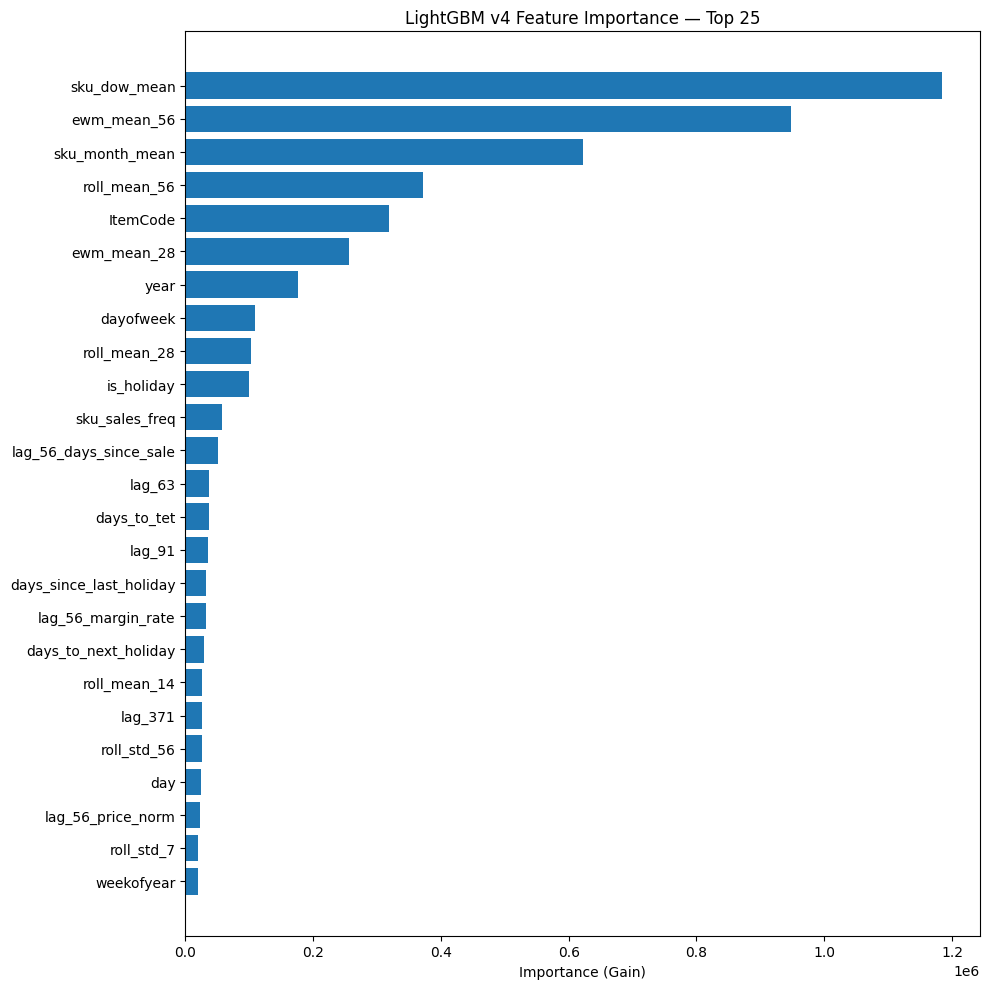

In [57]:
i
m
p
o
r
t
 
m
a
t
p
l
o
t
l
i
b
.
p
y
p
l
o
t
 
a
s
 
p
l
t


i
m
p
o
r
t
a
n
c
e
_
d
f
 
=
 
p
d
.
D
a
t
a
F
r
a
m
e
(
{

 
 
 
 
'
f
e
a
t
u
r
e
'
:
 
 
 
 
m
o
d
e
l
.
f
e
a
t
u
r
e
_
n
a
m
e
(
)
,

 
 
 
 
'
i
m
p
o
r
t
a
n
c
e
'
:
 
m
o
d
e
l
.
f
e
a
t
u
r
e
_
i
m
p
o
r
t
a
n
c
e
(
i
m
p
o
r
t
a
n
c
e
_
t
y
p
e
=
'
g
a
i
n
'
)
,

}
)
.
s
o
r
t
_
v
a
l
u
e
s
(
'
i
m
p
o
r
t
a
n
c
e
'
,
 
a
s
c
e
n
d
i
n
g
=
F
a
l
s
e
)

p
r
i
n
t
(
'
T
o
p
 
2
5
 
f
e
a
t
u
r
e
s
 
b
y
 
g
a
i
n
:
'
)

p
r
i
n
t
(
i
m
p
o
r
t
a
n
c
e
_
d
f
.
h
e
a
d
(
2
5
)
.
t
o
_
s
t
r
i
n
g
(
i
n
d
e
x
=
F
a
l
s
e
)
)


f
i
g
,
 
a
x
 
=
 
p
l
t
.
s
u
b
p
l
o
t
s
(
f
i
g
s
i
z
e
=
(
1
0
,
 
1
0
)
)

t
o
p
2
5
 
=
 
i
m
p
o
r
t
a
n
c
e
_
d
f
.
h
e
a
d
(
2
5
)

a
x
.
b
a
r
h
(
t
o
p
2
5
[
'
f
e
a
t
u
r
e
'
]
[
:
:
-
1
]
,
 
t
o
p
2
5
[
'
i
m
p
o
r
t
a
n
c
e
'
]
[
:
:
-
1
]
)

a
x
.
s
e
t
_
x
l
a
b
e
l
(
'
I
m
p
o
r
t
a
n
c
e
 
(
G
a
i
n
)
'
)

a
x
.
s
e
t
_
t
i
t
l
e
(
'
L
i
g
h
t
G
B
M
 
v
4
 
F
e
a
t
u
r
e
 
I
m
p
o
r
t
a
n
c
e
 
—
 
T
o
p
 
2
5
'
)

p
l
t
.
t
i
g
h
t
_
l
a
y
o
u
t
(
)

p
l
t
.
s
a
v
e
f
i
g
(
O
U
T
P
U
T
_
D
I
R
 
/
 
'
f
e
a
t
u
r
e
_
i
m
p
o
r
t
a
n
c
e
_
v
4
.
p
n
g
'
,
 
d
p
i
=
1
2
0
)

p
l
t
.
s
h
o
w
(
)

-
-
-

#
#
 

 
C
e
l
l
 
1
3
 
—
 
F
o
r
e
c
a
s
t
 
S
e
t
u
p

In [58]:
a
l
l
_
s
k
u
s
 
 
=
 
d
a
i
l
y
[
'
I
t
e
m
C
o
d
e
'
]
.
c
a
t
.
c
a
t
e
g
o
r
i
e
s
.
t
o
l
i
s
t
(
)

a
l
l
_
f
o
r
e
c
a
s
t
_
d
a
t
e
s
 
=
 
p
d
.
d
a
t
e
_
r
a
n
g
e
(
V
A
L
_
S
T
A
R
T
,
 
E
V
A
L
_
E
N
D
,
 
f
r
e
q
=
'
D
'
)

p
r
i
n
t
(
f
'
F
o
r
e
c
a
s
t
:
 
{
a
l
l
_
f
o
r
e
c
a
s
t
_
d
a
t
e
s
[
0
]
.
d
a
t
e
(
)
}
 
\
u
2
1
9
2
 
{
a
l
l
_
f
o
r
e
c
a
s
t
_
d
a
t
e
s
[
-
1
]
.
d
a
t
e
(
)
}
 
(
{
l
e
n
(
a
l
l
_
f
o
r
e
c
a
s
t
_
d
a
t
e
s
)
}
 
d
a
y
s
)
'
)

p
r
i
n
t
(
f
'
T
o
t
a
l
 
i
n
f
e
r
e
n
c
e
 
r
o
w
s
:
 
{
l
e
n
(
a
l
l
_
s
k
u
s
)
:
,
}
 
\
u
0
0
d
7
 
{
l
e
n
(
a
l
l
_
f
o
r
e
c
a
s
t
_
d
a
t
e
s
)
}
 
=
 
{
l
e
n
(
a
l
l
_
s
k
u
s
)
*
l
e
n
(
a
l
l
_
f
o
r
e
c
a
s
t
_
d
a
t
e
s
)
:
,
}
'
)

Forecast: 2025-09-06 → 2025-10-31 (56 days)
Total inference rows: 15,972 × 56 = 894,432


-
-
-

#
#
 

 
C
e
l
l
 
1
4
 
—
 
5
6
-
D
a
y
 
I
n
f
e
r
e
n
c
e
 
(
O
p
t
i
m
i
z
e
d
 
P
i
p
e
l
i
n
e
)

In [59]:
p
r
i
n
t
(
'
G
e
n
e
r
a
t
i
n
g
 
v
4
 
o
p
t
i
m
i
z
e
d
 
5
6
-
d
a
y
 
f
o
r
e
c
a
s
t
s
 
.
.
.
'
)


#
 
P
r
e
-
c
o
m
p
u
t
e
 
f
u
l
l
 
h
i
s
t
o
r
y
 
p
i
v
o
t
 
O
N
C
E
 
o
u
t
s
i
d
e
 
t
h
e
 
l
o
o
p
.

#
 
T
h
i
s
 
e
l
i
m
i
n
a
t
e
s
 
t
h
e
 
O
(
N
^
2
)
 
p
i
v
o
t
 
r
e
b
u
i
l
d
 
t
h
a
t
 
s
l
o
w
e
d
 
d
o
w
n
 
v
3
.

#
 
A
l
l
 
l
a
g
 
l
o
o
k
u
p
s
 
t
a
r
g
e
t
 
d
a
t
e
s
 
i
n
 
[
T
R
A
I
N
_
E
N
D
-
4
0
0
d
,
 
T
R
A
I
N
_
E
N
D
]
,
 
s
o
 
t
h
e
 
p
i
v
o
t

#
 
c
o
v
e
r
s
 
t
h
e
 
f
u
l
l
 
n
e
c
e
s
s
a
r
y
 
w
i
n
d
o
w
 
f
r
o
m
 
t
h
e
 
s
t
a
r
t
.

H
I
S
T
O
R
Y
_
S
T
A
R
T
 
=
 
T
R
A
I
N
_
E
N
D
 
-
 
p
d
.
T
i
m
e
d
e
l
t
a
(
d
a
y
s
=
4
0
0
)

h
i
s
t
o
r
y
_
d
f
 
 
 
 
=
 
d
a
i
l
y
[
d
a
i
l
y
[
'
D
a
t
e
'
]
 
>
=
 
H
I
S
T
O
R
Y
_
S
T
A
R
T
]
[
[

 
 
 
 
'
I
t
e
m
C
o
d
e
'
,
 
'
D
a
t
e
'
,
 
'
Q
u
a
n
t
i
t
y
'
,
 
'
l
a
g
_
5
6
_
p
r
i
c
e
_
n
o
r
m
'
,

 
 
 
 
'
l
a
g
_
5
6
_
i
s
_
d
i
s
c
o
u
n
t
'
,
 
'
l
a
g
_
5
6
_
m
a
r
g
i
n
_
r
a
t
e
'
,
 
'
l
a
g
_
5
6
_
d
a
y
s
_
s
i
n
c
e
_
s
a
l
e
'

]
]
.
c
o
p
y
(
)

h
i
s
t
_
p
i
v
o
t
 
=
 
h
i
s
t
o
r
y
_
d
f
.
p
i
v
o
t
(
i
n
d
e
x
=
'
I
t
e
m
C
o
d
e
'
,
 
c
o
l
u
m
n
s
=
'
D
a
t
e
'
,
 
v
a
l
u
e
s
=
'
Q
u
a
n
t
i
t
y
'
)
.
f
i
l
l
n
a
(
0
)

h
i
s
t
_
c
o
l
s
_
s
e
t
 
=
 
s
e
t
(
h
i
s
t
_
p
i
v
o
t
.
c
o
l
u
m
n
s
)
 
 
#
 
f
a
s
t
 
m
e
m
b
e
r
s
h
i
p
 
c
h
e
c
k


h
o
l
i
d
a
y
_
d
a
t
e
s
_
s
o
r
t
e
d
 
=
 
s
o
r
t
e
d
(
V
N
_
H
O
L
I
D
A
Y
S
)

t
r
a
i
n
_
s
u
m
s
 
 
 
 
 
 
 
 
 
 
 
=
 
d
a
i
l
y
.
g
r
o
u
p
b
y
(
'
I
t
e
m
C
o
d
e
'
)
[
'
Q
u
a
n
t
i
t
y
'
]
.
s
u
m
(
)
.
t
o
_
d
i
c
t
(
)

a
c
t
i
v
e
_
d
a
y
s
_
m
a
p
_
i
n
f
 
 
=
 
d
a
i
l
y
.
g
r
o
u
p
b
y
(
'
I
t
e
m
C
o
d
e
'
)
[
'
s
k
u
_
a
c
t
i
v
e
_
d
a
y
s
'
]
.
f
i
r
s
t
(
)
.
t
o
_
d
i
c
t
(
)

f
r
e
q
_
m
a
p
 
 
 
 
 
 
 
 
 
 
 
 
 
=
 
d
a
i
l
y
.
s
e
t
_
i
n
d
e
x
(
'
I
t
e
m
C
o
d
e
'
)
[
'
s
k
u
_
s
a
l
e
s
_
f
r
e
q
'
]
.
t
o
_
d
i
c
t
(
)


#
 
C
r
o
s
s
-
f
e
a
t
u
r
e
 
m
a
p
s
 
(
f
r
o
m
 
f
u
l
l
 
t
r
a
i
n
i
n
g
 
d
a
t
a
,
 
n
o
 
l
o
o
k
-
a
h
e
a
d
)

t
r
a
i
n
_
m
a
s
k
 
 
 
 
 
 
=
 
d
a
i
l
y
[
'
D
a
t
e
'
]
 
<
 
S
P
L
I
T
_
D
A
T
E

s
k
u
_
m
a
p
_
i
n
f
 
 
 
 
 
=
 
d
a
i
l
y
[
t
r
a
i
n
_
m
a
s
k
]
.
g
r
o
u
p
b
y
(
'
I
t
e
m
C
o
d
e
'
,
 
o
b
s
e
r
v
e
d
=
T
r
u
e
)
[
'
Q
u
a
n
t
i
t
y
'
]
.
m
e
a
n
(
)
.
t
o
_
d
i
c
t
(
)

d
o
w
_
m
a
p
_
i
n
f
 
 
 
 
 
=
 
d
a
i
l
y
[
t
r
a
i
n
_
m
a
s
k
]
.
g
r
o
u
p
b
y
(
[
'
I
t
e
m
C
o
d
e
'
,
 
'
d
a
y
o
f
w
e
e
k
'
]
,
 
o
b
s
e
r
v
e
d
=
T
r
u
e
)
[
'
Q
u
a
n
t
i
t
y
'
]
.
m
e
a
n
(
)
.
t
o
_
d
i
c
t
(
)

m
o
n
t
h
_
m
a
p
_
i
n
f
 
 
 
=
 
d
a
i
l
y
[
t
r
a
i
n
_
m
a
s
k
]
.
g
r
o
u
p
b
y
(
[
'
I
t
e
m
C
o
d
e
'
,
 
'
m
o
n
t
h
'
]
,
 
o
b
s
e
r
v
e
d
=
T
r
u
e
)
[
'
Q
u
a
n
t
i
t
y
'
]
.
m
e
a
n
(
)
.
t
o
_
d
i
c
t
(
)


#
 
S
t
a
t
i
c
 
p
e
r
-
S
K
U
 
f
e
a
t
u
r
e
s

s
k
u
_
m
e
d
i
a
n
_
m
a
p
 
 
=
 
d
a
i
l
y
.
g
r
o
u
p
b
y
(
'
I
t
e
m
C
o
d
e
'
)
[
'
s
k
u
_
m
e
d
i
a
n
_
q
t
y
'
]
.
f
i
r
s
t
(
)
.
t
o
_
d
i
c
t
(
)

s
k
u
_
c
v
_
m
a
p
 
 
 
 
 
 
=
 
d
a
i
l
y
.
g
r
o
u
p
b
y
(
'
I
t
e
m
C
o
d
e
'
)
[
'
s
k
u
_
c
v
'
]
.
f
i
r
s
t
(
)
.
t
o
_
d
i
c
t
(
)


#
 
P
r
i
c
e
/
m
a
r
g
i
n
/
s
t
r
e
a
k
 
f
r
o
m
 
l
a
s
t
 
k
n
o
w
n
 
h
i
s
t
o
r
i
c
a
l
 
v
a
l
u
e

l
a
s
t
_
p
r
i
c
e
_
n
o
r
m
_
m
a
p
 
 
=
 
h
i
s
t
o
r
y
_
d
f
.
g
r
o
u
p
b
y
(
'
I
t
e
m
C
o
d
e
'
)
[
'
l
a
g
_
5
6
_
p
r
i
c
e
_
n
o
r
m
'
]
.
l
a
s
t
(
)
.
t
o
_
d
i
c
t
(
)

l
a
s
t
_
i
s
_
d
i
s
c
o
u
n
t
_
m
a
p
 
=
 
h
i
s
t
o
r
y
_
d
f
.
g
r
o
u
p
b
y
(
'
I
t
e
m
C
o
d
e
'
)
[
'
l
a
g
_
5
6
_
i
s
_
d
i
s
c
o
u
n
t
'
]
.
l
a
s
t
(
)
.
t
o
_
d
i
c
t
(
)

l
a
s
t
_
m
a
r
g
i
n
_
r
a
t
e
_
m
a
p
 
=
 
h
i
s
t
o
r
y
_
d
f
.
g
r
o
u
p
b
y
(
'
I
t
e
m
C
o
d
e
'
)
[
'
l
a
g
_
5
6
_
m
a
r
g
i
n
_
r
a
t
e
'
]
.
l
a
s
t
(
)
.
t
o
_
d
i
c
t
(
)

l
a
s
t
_
s
t
r
e
a
k
_
m
a
p
 
 
 
 
 
 
=
 
h
i
s
t
o
r
y
_
d
f
.
g
r
o
u
p
b
y
(
'
I
t
e
m
C
o
d
e
'
)
[
'
l
a
g
_
5
6
_
d
a
y
s
_
s
i
n
c
e
_
s
a
l
e
'
]
.
l
a
s
t
(
)
.
t
o
_
d
i
c
t
(
)


#
 
P
r
o
f
i
t
 
w
e
i
g
h
t
s
 
f
o
r
 
t
i
e
r
e
d
 
p
o
s
t
-
p
r
o
c
e
s
s
i
n
g

p
r
o
f
i
t
_
w
m
a
p
_
i
n
f
 
=
 
s
k
u
_
p
r
o
f
i
t
_
v
a
l
.
s
e
t
_
i
n
d
e
x
(
'
I
t
e
m
C
o
d
e
'
)
[
'
w
e
i
g
h
t
'
]
.
t
o
_
d
i
c
t
(
)

a
l
l
_
w
e
i
g
h
t
s
_
a
r
r
 
=
 
n
p
.
a
r
r
a
y
(
[
p
r
o
f
i
t
_
w
m
a
p
_
i
n
f
.
g
e
t
(
s
,
 
0
.
0
)
 
f
o
r
 
s
 
i
n
 
a
l
l
_
s
k
u
s
]
)

p
o
s
_
w
_
a
r
r
 
=
 
a
l
l
_
w
e
i
g
h
t
s
_
a
r
r
[
a
l
l
_
w
e
i
g
h
t
s
_
a
r
r
 
>
 
0
]

w
9
5
_
i
n
f
 
=
 
f
l
o
a
t
(
n
p
.
q
u
a
n
t
i
l
e
(
p
o
s
_
w
_
a
r
r
,
 
0
.
9
5
)
)
 
i
f
 
l
e
n
(
p
o
s
_
w
_
a
r
r
)
 
e
l
s
e
 
1
.
0

w
8
0
_
i
n
f
 
=
 
f
l
o
a
t
(
n
p
.
q
u
a
n
t
i
l
e
(
p
o
s
_
w
_
a
r
r
,
 
0
.
8
0
)
)
 
i
f
 
l
e
n
(
p
o
s
_
w
_
a
r
r
)
 
e
l
s
e
 
1
.
0

w
5
0
_
i
n
f
 
=
 
f
l
o
a
t
(
n
p
.
q
u
a
n
t
i
l
e
(
p
o
s
_
w
_
a
r
r
,
 
0
.
5
0
)
)
 
i
f
 
l
e
n
(
p
o
s
_
w
_
a
r
r
)
 
e
l
s
e
 
1
.
0


#
 
P
r
e
c
o
m
p
u
t
e
 
b
o
o
l
e
a
n
 
t
i
e
r
 
m
a
s
k
s
 
(
s
a
m
e
 
f
o
r
 
e
v
e
r
y
 
f
o
r
e
c
a
s
t
 
d
a
y
 
—
 
w
e
i
g
h
t
s
 
a
r
e
 
s
t
a
t
i
c
)

m
_
t
1
_
i
n
f
 
=
 
a
l
l
_
w
e
i
g
h
t
s
_
a
r
r
 
>
=
 
w
9
5
_
i
n
f

m
_
t
2
_
i
n
f
 
=
 
(
a
l
l
_
w
e
i
g
h
t
s
_
a
r
r
 
>
=
 
w
8
0
_
i
n
f
)
 
&
 
~
m
_
t
1
_
i
n
f

m
_
t
3
_
i
n
f
 
=
 
(
a
l
l
_
w
e
i
g
h
t
s
_
a
r
r
 
>
=
 
w
5
0
_
i
n
f
)
 
&
 
~
m
_
t
1
_
i
n
f
 
&
 
~
m
_
t
2
_
i
n
f


a
l
l
_
f
o
r
e
c
a
s
t
_
r
e
c
o
r
d
s
 
=
 
[
]


f
o
r
 
i
,
 
f
d
a
t
e
 
i
n
 
e
n
u
m
e
r
a
t
e
(
a
l
l
_
f
o
r
e
c
a
s
t
_
d
a
t
e
s
)
:

 
 
 
 
i
f
 
(
i
 
+
 
1
)
 
%
 
1
0
 
=
=
 
0
 
o
r
 
i
 
=
=
 
0
:

 
 
 
 
 
 
 
 
p
r
i
n
t
(
f
'
 
 
D
a
y
 
{
i
+
1
:
2
d
}
/
5
6
:
 
{
f
d
a
t
e
.
d
a
t
e
(
)
}
'
)

 
 
 
 

 
 
 
 
#
 
H
o
l
i
d
a
y
/
T
e
t
 
p
r
o
x
i
m
i
t
y
 
f
o
r
 
t
h
i
s
 
f
o
r
e
c
a
s
t
 
d
a
t
e

 
 
 
 
f
u
t
u
r
e
_
h
o
l
s
 
 
 
 
 
 
 
 
 
 
=
 
[
h
 
f
o
r
 
h
 
i
n
 
h
o
l
i
d
a
y
_
d
a
t
e
s
_
s
o
r
t
e
d
 
i
f
 
h
 
>
 
f
d
a
t
e
]

 
 
 
 
p
a
s
t
_
h
o
l
s
 
 
 
 
 
 
 
 
 
 
 
 
=
 
[
h
 
f
o
r
 
h
 
i
n
 
h
o
l
i
d
a
y
_
d
a
t
e
s
_
s
o
r
t
e
d
 
i
f
 
h
 
<
 
f
d
a
t
e
]

 
 
 
 
d
a
y
s
_
t
o
_
n
e
x
t
_
h
o
l
 
 
 
 
 
=
 
(
f
u
t
u
r
e
_
h
o
l
s
[
0
]
 
-
 
f
d
a
t
e
)
.
d
a
y
s
 
i
f
 
f
u
t
u
r
e
_
h
o
l
s
 
e
l
s
e
 
3
6
5

 
 
 
 
d
a
y
s
_
s
i
n
c
e
_
l
a
s
t
_
h
o
l
 
 
=
 
(
f
d
a
t
e
 
-
 
p
a
s
t
_
h
o
l
s
[
-
1
]
)
.
d
a
y
s
 
 
i
f
 
p
a
s
t
_
h
o
l
s
 
 
e
l
s
e
 
3
6
5

 
 
 
 
f
u
t
u
r
e
_
t
e
t
 
=
 
[
t
 
f
o
r
 
t
 
i
n
 
T
E
T
_
D
A
Y
1
_
L
I
S
T
 
i
f
 
t
 
>
 
f
d
a
t
e
]

 
 
 
 
p
a
s
t
_
t
e
t
 
 
 
=
 
[
t
 
f
o
r
 
t
 
i
n
 
T
E
T
_
D
A
Y
1
_
L
I
S
T
 
i
f
 
t
 
<
=
 
f
d
a
t
e
]

 
 
 
 
d
_
t
o
_
t
e
t
 
 
 
=
 
(
f
u
t
u
r
e
_
t
e
t
[
0
]
 
-
 
f
d
a
t
e
)
.
d
a
y
s
 
i
f
 
f
u
t
u
r
e
_
t
e
t
 
e
l
s
e
 
3
6
5

 
 
 
 
d
_
f
r
o
m
_
t
e
t
 
=
 
(
f
d
a
t
e
 
-
 
p
a
s
t
_
t
e
t
[
-
1
]
)
.
d
a
y
s
 
 
 
i
f
 
p
a
s
t
_
t
e
t
 
 
 
e
l
s
e
 
3
6
5

 
 
 
 

 
 
 
 
r
o
w
_
d
f
 
=
 
p
d
.
D
a
t
a
F
r
a
m
e
(
{
'
I
t
e
m
C
o
d
e
'
:
 
a
l
l
_
s
k
u
s
}
)

 
 
 
 

 
 
 
 
#
 
L
a
g
 
f
e
a
t
u
r
e
s
 
(
a
l
l
 
>
=
 
5
6
 
d
a
y
s
 
b
a
c
k
,
 
s
o
 
a
l
w
a
y
s
 
i
n
 
h
i
s
t
o
r
i
c
a
l
 
d
a
t
a
)

 
 
 
 
f
o
r
 
l
a
g
 
i
n
 
[
5
6
,
 
6
3
,
 
7
0
,
 
8
4
,
 
9
1
,
 
3
5
7
,
 
3
6
4
,
 
3
7
1
]
:

 
 
 
 
 
 
 
 
l
a
g
_
d
a
t
e
 
=
 
f
d
a
t
e
 
-
 
p
d
.
T
i
m
e
d
e
l
t
a
(
d
a
y
s
=
l
a
g
)

 
 
 
 
 
 
 
 
i
f
 
l
a
g
_
d
a
t
e
 
i
n
 
h
i
s
t
_
c
o
l
s
_
s
e
t
:

 
 
 
 
 
 
 
 
 
 
 
 
r
o
w
_
d
f
[
f
'
l
a
g
_
{
l
a
g
}
'
]
 
=
 
h
i
s
t
_
p
i
v
o
t
[
l
a
g
_
d
a
t
e
]
.
r
e
i
n
d
e
x
(
a
l
l
_
s
k
u
s
)
.
f
i
l
l
n
a
(
0
)
.
v
a
l
u
e
s

 
 
 
 
 
 
 
 
e
l
s
e
:

 
 
 
 
 
 
 
 
 
 
 
 
r
o
w
_
d
f
[
f
'
l
a
g
_
{
l
a
g
}
'
]
 
=
 
0
.
0

 
 
 
 

 
 
 
 
#
 
R
o
l
l
i
n
g
 
m
e
a
n
/
s
t
d
 
f
r
o
m
 
l
a
g
-
5
6
 
w
i
n
d
o
w

 
 
 
 
l
a
g
5
6
_
d
a
t
e
 
=
 
f
d
a
t
e
 
-
 
p
d
.
T
i
m
e
d
e
l
t
a
(
d
a
y
s
=
5
6
)

 
 
 
 
f
o
r
 
w
i
n
d
o
w
 
i
n
 
[
7
,
 
1
4
,
 
2
8
,
 
5
6
]
:

 
 
 
 
 
 
 
 
w
i
n
d
o
w
_
s
t
a
r
t
 
=
 
l
a
g
5
6
_
d
a
t
e
 
-
 
p
d
.
T
i
m
e
d
e
l
t
a
(
d
a
y
s
=
w
i
n
d
o
w
 
-
 
1
)

 
 
 
 
 
 
 
 
d
a
t
e
s
_
i
n
_
w
i
n
 
=
 
[
d
 
f
o
r
 
d
 
i
n
 
h
i
s
t
_
p
i
v
o
t
.
c
o
l
u
m
n
s
 
i
f
 
w
i
n
d
o
w
_
s
t
a
r
t
 
<
=
 
d
 
<
=
 
l
a
g
5
6
_
d
a
t
e
]

 
 
 
 
 
 
 
 
i
f
 
d
a
t
e
s
_
i
n
_
w
i
n
:

 
 
 
 
 
 
 
 
 
 
 
 
w
v
 
=
 
h
i
s
t
_
p
i
v
o
t
[
d
a
t
e
s
_
i
n
_
w
i
n
]
.
r
e
i
n
d
e
x
(
a
l
l
_
s
k
u
s
)
.
f
i
l
l
n
a
(
0
)

 
 
 
 
 
 
 
 
 
 
 
 
r
o
w
_
d
f
[
f
'
r
o
l
l
_
m
e
a
n
_
{
w
i
n
d
o
w
}
'
]
 
=
 
w
v
.
m
e
a
n
(
a
x
i
s
=
1
)
.
v
a
l
u
e
s

 
 
 
 
 
 
 
 
 
 
 
 
r
o
w
_
d
f
[
f
'
r
o
l
l
_
s
t
d
_
{
w
i
n
d
o
w
}
'
]
 
 
=
 
w
v
.
s
t
d
(
a
x
i
s
=
1
)
.
f
i
l
l
n
a
(
0
)
.
v
a
l
u
e
s

 
 
 
 
 
 
 
 
e
l
s
e
:

 
 
 
 
 
 
 
 
 
 
 
 
r
o
w
_
d
f
[
f
'
r
o
l
l
_
m
e
a
n
_
{
w
i
n
d
o
w
}
'
]
 
=
 
r
o
w
_
d
f
[
f
'
r
o
l
l
_
s
t
d
_
{
w
i
n
d
o
w
}
'
]
 
=
 
0
.
0

 
 
 
 

 
 
 
 
#
 
E
W
M
 
f
e
a
t
u
r
e
s

 
 
 
 
f
o
r
 
s
p
a
n
 
i
n
 
[
2
8
,
 
5
6
]
:

 
 
 
 
 
 
 
 
s
p
a
n
_
s
t
a
r
t
 
=
 
l
a
g
5
6
_
d
a
t
e
 
-
 
p
d
.
T
i
m
e
d
e
l
t
a
(
d
a
y
s
=
s
p
a
n
 
*
 
3
)

 
 
 
 
 
 
 
 
d
a
t
e
s
_
e
w
m
 
 
=
 
[
d
 
f
o
r
 
d
 
i
n
 
h
i
s
t
_
p
i
v
o
t
.
c
o
l
u
m
n
s
 
i
f
 
s
p
a
n
_
s
t
a
r
t
 
<
=
 
d
 
<
=
 
l
a
g
5
6
_
d
a
t
e
]

 
 
 
 
 
 
 
 
i
f
 
d
a
t
e
s
_
e
w
m
:

 
 
 
 
 
 
 
 
 
 
 
 
e
v
 
=
 
h
i
s
t
_
p
i
v
o
t
[
d
a
t
e
s
_
e
w
m
]
.
r
e
i
n
d
e
x
(
a
l
l
_
s
k
u
s
)
.
f
i
l
l
n
a
(
0
)

 
 
 
 
 
 
 
 
 
 
 
 
r
o
w
_
d
f
[
f
'
e
w
m
_
m
e
a
n
_
{
s
p
a
n
}
'
]
 
=
 
e
v
.
a
p
p
l
y
(

 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
l
a
m
b
d
a
 
x
:
 
x
.
e
w
m
(
s
p
a
n
=
s
p
a
n
,
 
m
i
n
_
p
e
r
i
o
d
s
=
1
)
.
m
e
a
n
(
)
.
i
l
o
c
[
-
1
]
,
 
a
x
i
s
=
1

 
 
 
 
 
 
 
 
 
 
 
 
)
.
v
a
l
u
e
s

 
 
 
 
 
 
 
 
e
l
s
e
:

 
 
 
 
 
 
 
 
 
 
 
 
r
o
w
_
d
f
[
f
'
e
w
m
_
m
e
a
n
_
{
s
p
a
n
}
'
]
 
=
 
0
.
0

 
 
 
 

 
 
 
 
#
 
S
t
a
t
i
c
 
S
K
U
-
l
e
v
e
l
 
f
e
a
t
u
r
e
s

 
 
 
 
r
o
w
_
d
f
[
'
s
k
u
_
s
a
l
e
s
_
f
r
e
q
'
]
 
 
=
 
r
o
w
_
d
f
[
'
I
t
e
m
C
o
d
e
'
]
.
m
a
p
(
f
r
e
q
_
m
a
p
)
.
f
i
l
l
n
a
(
0
)
.
v
a
l
u
e
s

 
 
 
 
r
o
w
_
d
f
[
'
s
k
u
_
a
c
t
i
v
e
_
d
a
y
s
'
]
 
=
 
r
o
w
_
d
f
[
'
I
t
e
m
C
o
d
e
'
]
.
m
a
p
(
a
c
t
i
v
e
_
d
a
y
s
_
m
a
p
_
i
n
f
)
.
f
i
l
l
n
a
(
0
)
.
v
a
l
u
e
s

 
 
 
 
r
o
w
_
d
f
[
'
s
k
u
_
m
e
d
i
a
n
_
q
t
y
'
]
 
 
=
 
r
o
w
_
d
f
[
'
I
t
e
m
C
o
d
e
'
]
.
m
a
p
(
s
k
u
_
m
e
d
i
a
n
_
m
a
p
)
.
f
i
l
l
n
a
(
0
)
.
v
a
l
u
e
s

 
 
 
 
r
o
w
_
d
f
[
'
s
k
u
_
c
v
'
]
 
 
 
 
 
 
 
 
 
 
=
 
r
o
w
_
d
f
[
'
I
t
e
m
C
o
d
e
'
]
.
m
a
p
(
s
k
u
_
c
v
_
m
a
p
)
.
f
i
l
l
n
a
(
0
)
.
v
a
l
u
e
s

 
 
 
 

 
 
 
 
#
 
C
a
l
e
n
d
a
r
 
f
e
a
t
u
r
e
s
 
f
o
r
 
t
h
i
s
 
d
a
t
e

 
 
 
 
i
s
o
_
w
 
=
 
f
d
a
t
e
.
i
s
o
c
a
l
e
n
d
a
r
(
)
[
1
]

 
 
 
 
t
i
m
e
_
f
e
a
t
s
 
=
 
{

 
 
 
 
 
 
 
 
'
d
a
y
o
f
w
e
e
k
'
:
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
f
d
a
t
e
.
d
a
y
o
f
w
e
e
k
,

 
 
 
 
 
 
 
 
'
d
a
y
'
:
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
f
d
a
t
e
.
d
a
y
,

 
 
 
 
 
 
 
 
'
m
o
n
t
h
'
:
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
f
d
a
t
e
.
m
o
n
t
h
,

 
 
 
 
 
 
 
 
'
y
e
a
r
'
:
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
f
d
a
t
e
.
y
e
a
r
,

 
 
 
 
 
 
 
 
'
q
u
a
r
t
e
r
'
:
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
f
d
a
t
e
.
q
u
a
r
t
e
r
,

 
 
 
 
 
 
 
 
'
w
e
e
k
o
f
y
e
a
r
'
:
 
 
 
 
 
 
 
 
 
 
 
 
 
 
i
s
o
_
w
,

 
 
 
 
 
 
 
 
'
d
a
y
s
_
i
n
_
m
o
n
t
h
'
:
 
 
 
 
 
 
 
 
 
 
 
f
d
a
t
e
.
d
a
y
s
_
i
n
_
m
o
n
t
h
,

 
 
 
 
 
 
 
 
'
i
s
_
w
e
e
k
e
n
d
'
:
 
 
 
 
 
 
 
 
 
 
 
 
 
 
i
n
t
(
f
d
a
t
e
.
d
a
y
o
f
w
e
e
k
 
>
=
 
5
)
,

 
 
 
 
 
 
 
 
'
i
s
_
m
o
n
t
h
_
s
t
a
r
t
'
:
 
 
 
 
 
 
 
 
 
 
i
n
t
(
f
d
a
t
e
.
d
a
y
 
<
=
 
3
)
,

 
 
 
 
 
 
 
 
'
i
s
_
m
o
n
t
h
_
e
n
d
'
:
 
 
 
 
 
 
 
 
 
 
 
 
i
n
t
(
f
d
a
t
e
.
d
a
y
 
>
=
 
2
8
)
,

 
 
 
 
 
 
 
 
'
i
s
_
h
o
l
i
d
a
y
'
:
 
 
 
 
 
 
 
 
 
 
 
 
 
 
i
n
t
(
f
d
a
t
e
 
i
n
 
V
N
_
H
O
L
I
D
A
Y
S
)
,

 
 
 
 
 
 
 
 
'
d
a
y
s
_
t
o
_
n
e
x
t
_
h
o
l
i
d
a
y
'
:
 
 
 
 
d
a
y
s
_
t
o
_
n
e
x
t
_
h
o
l
,

 
 
 
 
 
 
 
 
'
d
a
y
s
_
s
i
n
c
e
_
l
a
s
t
_
h
o
l
i
d
a
y
'
:
 
d
a
y
s
_
s
i
n
c
e
_
l
a
s
t
_
h
o
l
,

 
 
 
 
 
 
 
 
'
i
s
_
p
r
e
_
h
o
l
i
d
a
y
_
1
4
d
'
:
 
 
 
 
 
 
1
 
i
f
 
(
0
 
<
 
d
a
y
s
_
t
o
_
n
e
x
t
_
h
o
l
 
 
<
=
 
1
4
)
 
e
l
s
e
 
0
,

 
 
 
 
 
 
 
 
'
i
s
_
p
r
e
_
h
o
l
i
d
a
y
_
7
d
'
:
 
 
 
 
 
 
 
1
 
i
f
 
(
0
 
<
 
d
a
y
s
_
t
o
_
n
e
x
t
_
h
o
l
 
 
<
=
 
7
)
 
 
e
l
s
e
 
0
,

 
 
 
 
 
 
 
 
'
i
s
_
p
o
s
t
_
h
o
l
i
d
a
y
_
7
d
'
:
 
 
 
 
 
 
1
 
i
f
 
(
0
 
<
 
d
a
y
s
_
s
i
n
c
e
_
l
a
s
t
_
h
o
l
 
<
=
 
7
)
 
e
l
s
e
 
0
,

 
 
 
 
 
 
 
 
'
i
s
_
p
o
s
t
_
h
o
l
i
d
a
y
_
3
d
'
:
 
 
 
 
 
 
1
 
i
f
 
(
0
 
<
 
d
a
y
s
_
s
i
n
c
e
_
l
a
s
t
_
h
o
l
 
<
=
 
3
)
 
e
l
s
e
 
0
,

 
 
 
 
 
 
 
 
'
d
a
y
s
_
t
o
_
t
e
t
'
:
 
 
 
 
 
 
 
 
 
 
 
 
 
m
i
n
(
d
_
t
o
_
t
e
t
,
 
3
6
5
)
,

 
 
 
 
 
 
 
 
'
d
a
y
s
_
s
i
n
c
e
_
t
e
t
'
:
 
 
 
 
 
 
 
 
 
 
m
i
n
(
d
_
f
r
o
m
_
t
e
t
,
 
3
6
5
)
,

 
 
 
 
 
 
 
 
'
i
s
_
t
e
t
_
s
e
a
s
o
n
'
:
 
 
 
 
 
 
 
 
 
 
 
1
 
i
f
 
(
d
_
t
o
_
t
e
t
 
<
=
 
3
0
 
o
r
 
d
_
f
r
o
m
_
t
e
t
 
<
=
 
3
0
)
 
e
l
s
e
 
0
,

 
 
 
 
}

 
 
 
 
f
o
r
 
k
,
 
v
 
i
n
 
t
i
m
e
_
f
e
a
t
s
.
i
t
e
m
s
(
)
:

 
 
 
 
 
 
 
 
r
o
w
_
d
f
[
k
]
 
=
 
v

 
 
 
 

 
 
 
 
#
 
C
r
o
s
s
 
f
e
a
t
u
r
e
s

 
 
 
 
r
o
w
_
d
f
[
'
s
k
u
_
m
e
a
n
_
q
t
y
'
]
 
=
 
r
o
w
_
d
f
[
'
I
t
e
m
C
o
d
e
'
]
.
m
a
p
(
s
k
u
_
m
a
p
_
i
n
f
)
.
f
i
l
l
n
a
(
0
)
.
a
s
t
y
p
e
(
'
f
l
o
a
t
3
2
'
)

 
 
 
 
d
k
 
=
 
p
d
.
M
u
l
t
i
I
n
d
e
x
.
f
r
o
m
_
a
r
r
a
y
s
(
[
r
o
w
_
d
f
[
'
I
t
e
m
C
o
d
e
'
]
,
 
r
o
w
_
d
f
[
'
d
a
y
o
f
w
e
e
k
'
]
]
)

 
 
 
 
r
o
w
_
d
f
[
'
s
k
u
_
d
o
w
_
m
e
a
n
'
]
 
=
 
d
k
.
m
a
p
(
d
o
w
_
m
a
p
_
i
n
f
)
.
f
i
l
l
n
a
(
0
)
.
a
s
t
y
p
e
(
'
f
l
o
a
t
3
2
'
)

 
 
 
 
m
k
 
=
 
p
d
.
M
u
l
t
i
I
n
d
e
x
.
f
r
o
m
_
a
r
r
a
y
s
(
[
r
o
w
_
d
f
[
'
I
t
e
m
C
o
d
e
'
]
,
 
r
o
w
_
d
f
[
'
m
o
n
t
h
'
]
]
)

 
 
 
 
r
o
w
_
d
f
[
'
s
k
u
_
m
o
n
t
h
_
m
e
a
n
'
]
 
=
 
m
k
.
m
a
p
(
m
o
n
t
h
_
m
a
p
_
i
n
f
)
.
f
i
l
l
n
a
(
0
)
.
a
s
t
y
p
e
(
'
f
l
o
a
t
3
2
'
)

 
 
 
 

 
 
 
 
#
 
P
r
i
c
e
/
m
a
r
g
i
n
/
s
t
r
e
a
k

 
 
 
 
r
o
w
_
d
f
[
'
l
a
g
_
5
6
_
p
r
i
c
e
_
n
o
r
m
'
]
 
 
 
 
 
 
=
 
r
o
w
_
d
f
[
'
I
t
e
m
C
o
d
e
'
]
.
m
a
p
(
l
a
s
t
_
p
r
i
c
e
_
n
o
r
m
_
m
a
p
)
.
f
i
l
l
n
a
(
1
.
0
)
.
v
a
l
u
e
s

 
 
 
 
r
o
w
_
d
f
[
'
l
a
g
_
5
6
_
i
s
_
d
i
s
c
o
u
n
t
'
]
 
 
 
 
 
=
 
r
o
w
_
d
f
[
'
I
t
e
m
C
o
d
e
'
]
.
m
a
p
(
l
a
s
t
_
i
s
_
d
i
s
c
o
u
n
t
_
m
a
p
)
.
f
i
l
l
n
a
(
0
)
.
v
a
l
u
e
s

 
 
 
 
r
o
w
_
d
f
[
'
l
a
g
_
5
6
_
m
a
r
g
i
n
_
r
a
t
e
'
]
 
 
 
 
 
=
 
r
o
w
_
d
f
[
'
I
t
e
m
C
o
d
e
'
]
.
m
a
p
(
l
a
s
t
_
m
a
r
g
i
n
_
r
a
t
e
_
m
a
p
)
.
f
i
l
l
n
a
(
0
)
.
v
a
l
u
e
s

 
 
 
 
r
o
w
_
d
f
[
'
l
a
g
_
5
6
_
d
a
y
s
_
s
i
n
c
e
_
s
a
l
e
'
]
 
=
 
r
o
w
_
d
f
[
'
I
t
e
m
C
o
d
e
'
]
.
m
a
p
(
l
a
s
t
_
s
t
r
e
a
k
_
m
a
p
)
.
f
i
l
l
n
a
(
0
)
.
v
a
l
u
e
s
 
+
 
i

 
 
 
 

 
 
 
 
r
o
w
_
d
f
[
'
D
a
t
e
'
]
 
 
 
 
 
=
 
f
d
a
t
e

 
 
 
 
r
o
w
_
d
f
[
'
I
t
e
m
C
o
d
e
'
]
 
=
 
r
o
w
_
d
f
[
'
I
t
e
m
C
o
d
e
'
]
.
a
s
t
y
p
e
(
'
c
a
t
e
g
o
r
y
'
)

 
 
 
 

 
 
 
 
#
 
P
r
e
d
i
c
t
 
(
s
q
r
t
-
s
p
a
c
e
 

 
s
q
u
a
r
e
 
b
a
c
k
 
t
o
 
q
u
a
n
t
i
t
y
)

 
 
 
 
p
r
e
d
s
 
=
 
n
p
.
s
q
u
a
r
e
(
n
p
.
c
l
i
p
(

 
 
 
 
 
 
 
 
m
o
d
e
l
.
p
r
e
d
i
c
t
(
r
o
w
_
d
f
[
F
E
A
T
U
R
E
_
C
O
L
S
]
,
 
n
u
m
_
i
t
e
r
a
t
i
o
n
=
m
o
d
e
l
.
b
e
s
t
_
i
t
e
r
a
t
i
o
n
)
,
 
0
,
 
N
o
n
e

 
 
 
 
)
)

 
 
 
 
r
o
w
_
d
f
[
'
f
o
r
e
c
a
s
t
'
]
 
=
 
p
r
e
d
s

 
 
 
 

 
 
 
 
#
 
S
p
a
r
s
e
 
S
K
U
 
z
e
r
o
i
n
g

 
 
 
 
r
o
w
_
d
f
[
'
t
r
a
i
n
_
s
u
m
'
]
 
 
 
 
 
=
 
r
o
w
_
d
f
[
'
I
t
e
m
C
o
d
e
'
]
.
m
a
p
(
t
r
a
i
n
_
s
u
m
s
)
.
f
i
l
l
n
a
(
0
.
0
)

 
 
 
 
r
o
w
_
d
f
[
'
a
c
t
i
v
e
_
d
a
y
s
_
v
'
]
 
=
 
r
o
w
_
d
f
[
'
I
t
e
m
C
o
d
e
'
]
.
m
a
p
(
a
c
t
i
v
e
_
d
a
y
s
_
m
a
p
_
i
n
f
)
.
f
i
l
l
n
a
(
0
)

 
 
 
 
r
o
w
_
d
f
.
l
o
c
[
r
o
w
_
d
f
[
'
t
r
a
i
n
_
s
u
m
'
]
 
=
=
 
0
,
 
'
f
o
r
e
c
a
s
t
'
]
 
=
 
0
.
0

 
 
 
 
r
o
w
_
d
f
.
l
o
c
[
r
o
w
_
d
f
[
'
a
c
t
i
v
e
_
d
a
y
s
_
v
'
]
 
<
 
5
,
 
'
f
o
r
e
c
a
s
t
'
]
 
=
 
0
.
0

 
 
 
 

 
 
 
 
#
 
P
r
o
f
i
t
-
a
w
a
r
e
 
t
i
e
r
e
d
 
s
c
a
l
i
n
g

 
 
 
 
r
o
w
_
d
f
.
l
o
c
[
m
_
t
1
_
i
n
f
,
 
'
f
o
r
e
c
a
s
t
'
]
 
*
=
 
1
.
2
0

 
 
 
 
r
o
w
_
d
f
.
l
o
c
[
m
_
t
2
_
i
n
f
,
 
'
f
o
r
e
c
a
s
t
'
]
 
*
=
 
1
.
1
0

 
 
 
 
r
o
w
_
d
f
.
l
o
c
[
m
_
t
3
_
i
n
f
,
 
'
f
o
r
e
c
a
s
t
'
]
 
*
=
 
1
.
0
5

 
 
 
 

 
 
 
 
a
l
l
_
f
o
r
e
c
a
s
t
_
r
e
c
o
r
d
s
.
a
p
p
e
n
d
(
r
o
w
_
d
f
[
[
'
I
t
e
m
C
o
d
e
'
,
 
'
D
a
t
e
'
,
 
'
f
o
r
e
c
a
s
t
'
]
]
)


f
o
r
e
c
a
s
t
_
d
f
 
=
 
p
d
.
c
o
n
c
a
t
(
a
l
l
_
f
o
r
e
c
a
s
t
_
r
e
c
o
r
d
s
,
 
i
g
n
o
r
e
_
i
n
d
e
x
=
T
r
u
e
)

p
r
i
n
t
(
f
'
F
o
r
e
c
a
s
t
 
c
o
m
p
l
e
t
e
:
 
{
l
e
n
(
f
o
r
e
c
a
s
t
_
d
f
)
:
,
}
 
r
o
w
s
'
)



Generating v4 optimized 56-day forecasts ...
  Day  1/56: 2025-09-06
  Day 10/56: 2025-09-15
  Day 20/56: 2025-09-25
  Day 30/56: 2025-10-05
  Day 40/56: 2025-10-15
  Day 50/56: 2025-10-25
Forecast complete: 894,432 rows


-
-
-

#
#
 

 
C
e
l
l
 
1
5
 
—
 
B
u
i
l
d
 
&
 
V
a
l
i
d
a
t
e
 
S
u
b
m
i
s
s
i
o
n

In [60]:
s
a
m
p
l
e
_
s
u
b
 
=
 
p
d
.
r
e
a
d
_
c
s
v
(
S
A
M
P
L
E
_
P
A
T
H
)

p
r
i
n
t
(
f
'
S
a
m
p
l
e
 
s
u
b
m
i
s
s
i
o
n
:
 
{
s
a
m
p
l
e
_
s
u
b
.
s
h
a
p
e
}
'
)

a
s
s
e
r
t
 
s
a
m
p
l
e
_
s
u
b
.
s
h
a
p
e
[
1
]
 
=
=
 
2
9
,
 
f
'
E
x
p
e
c
t
e
d
 
2
9
 
c
o
l
s
 
(
i
d
 
+
 
F
1
.
.
F
2
8
)
,
 
g
o
t
 
{
s
a
m
p
l
e
_
s
u
b
.
s
h
a
p
e
[
1
]
}
'


F
_
C
O
L
S
 
 
 
 
 
=
 
[
f
'
F
{
i
}
'
 
f
o
r
 
i
 
i
n
 
r
a
n
g
e
(
1
,
 
2
9
)
]

v
a
l
_
d
a
t
e
s
 
 
=
 
p
d
.
d
a
t
e
_
r
a
n
g
e
(
V
A
L
_
S
T
A
R
T
,
 
 
V
A
L
_
E
N
D
,
 
 
f
r
e
q
=
'
D
'
)
 
 
 
#
 
2
8
 
d
a
y
s

e
v
a
l
_
d
a
t
e
s
 
=
 
p
d
.
d
a
t
e
_
r
a
n
g
e
(
E
V
A
L
_
S
T
A
R
T
,
 
E
V
A
L
_
E
N
D
,
 
f
r
e
q
=
'
D
'
)
 
 
 
#
 
2
8
 
d
a
y
s

a
s
s
e
r
t
 
l
e
n
(
v
a
l
_
d
a
t
e
s
)
 
=
=
 
2
8
 
a
n
d
 
l
e
n
(
e
v
a
l
_
d
a
t
e
s
)
 
=
=
 
2
8


f
c
_
p
i
v
o
t
 
=
 
f
o
r
e
c
a
s
t
_
d
f
.
p
i
v
o
t
(
i
n
d
e
x
=
'
I
t
e
m
C
o
d
e
'
,
 
c
o
l
u
m
n
s
=
'
D
a
t
e
'
,
 
v
a
l
u
e
s
=
'
f
o
r
e
c
a
s
t
'
)
.
f
i
l
l
n
a
(
0
)


s
u
b
m
i
s
s
i
o
n
_
r
o
w
s
 
=
 
[
]

f
o
r
 
i
d
x
_
r
o
w
 
i
n
 
s
a
m
p
l
e
_
s
u
b
.
i
t
e
r
t
u
p
l
e
s
(
i
n
d
e
x
=
F
a
l
s
e
)
:

 
 
 
 
r
o
w
_
i
d
 
=
 
i
d
x
_
r
o
w
.
i
d

 
 
 
 
i
f
 
'
_
v
a
l
i
d
a
t
i
o
n
'
 
i
n
 
r
o
w
_
i
d
:

 
 
 
 
 
 
 
 
s
k
u
,
 
d
a
t
e
s
 
=
 
r
o
w
_
i
d
.
r
e
p
l
a
c
e
(
'
_
v
a
l
i
d
a
t
i
o
n
'
,
 
'
'
)
,
 
v
a
l
_
d
a
t
e
s

 
 
 
 
e
l
i
f
 
'
_
e
v
a
l
u
a
t
i
o
n
'
 
i
n
 
r
o
w
_
i
d
:

 
 
 
 
 
 
 
 
s
k
u
,
 
d
a
t
e
s
 
=
 
r
o
w
_
i
d
.
r
e
p
l
a
c
e
(
'
_
e
v
a
l
u
a
t
i
o
n
'
,
 
'
'
)
,
 
e
v
a
l
_
d
a
t
e
s

 
 
 
 
e
l
s
e
:

 
 
 
 
 
 
 
 
r
a
i
s
e
 
V
a
l
u
e
E
r
r
o
r
(
f
'
U
n
e
x
p
e
c
t
e
d
 
i
d
 
f
o
r
m
a
t
:
 
{
r
o
w
_
i
d
}
'
)

 
 
 
 

 
 
 
 
p
r
e
d
s
_
2
8
 
=
 
n
p
.
c
l
i
p
(

 
 
 
 
 
 
 
 
f
c
_
p
i
v
o
t
.
l
o
c
[
s
k
u
,
 
d
a
t
e
s
]
.
v
a
l
u
e
s
 
i
f
 
s
k
u
 
i
n
 
f
c
_
p
i
v
o
t
.
i
n
d
e
x
 
e
l
s
e
 
n
p
.
z
e
r
o
s
(
2
8
)
,

 
 
 
 
 
 
 
 
0
,
 
N
o
n
e

 
 
 
 
)

 
 
 
 
r
o
w
 
=
 
{
'
i
d
'
:
 
r
o
w
_
i
d
}

 
 
 
 
r
o
w
.
u
p
d
a
t
e
(
{
f
'
F
{
i
+
1
}
'
:
 
f
l
o
a
t
(
p
r
e
d
s
_
2
8
[
i
]
)
 
f
o
r
 
i
 
i
n
 
r
a
n
g
e
(
2
8
)
}
)

 
 
 
 
s
u
b
m
i
s
s
i
o
n
_
r
o
w
s
.
a
p
p
e
n
d
(
r
o
w
)


s
u
b
m
i
s
s
i
o
n
 
=
 
p
d
.
D
a
t
a
F
r
a
m
e
(
s
u
b
m
i
s
s
i
o
n
_
r
o
w
s
)


a
s
s
e
r
t
 
l
e
n
(
s
u
b
m
i
s
s
i
o
n
)
 
=
=
 
l
e
n
(
s
a
m
p
l
e
_
s
u
b
)
,
 
 
 
 
 
 
 
 
 
 
 
 
 
'
R
o
w
 
c
o
u
n
t
 
m
i
s
m
a
t
c
h
!
'

a
s
s
e
r
t
 
s
e
t
(
s
u
b
m
i
s
s
i
o
n
[
'
i
d
'
]
)
 
=
=
 
s
e
t
(
s
a
m
p
l
e
_
s
u
b
[
'
i
d
'
]
)
,
 
'
I
D
 
s
e
t
 
m
i
s
m
a
t
c
h
!
'

a
s
s
e
r
t
 
s
u
b
m
i
s
s
i
o
n
[
F
_
C
O
L
S
]
.
i
s
n
a
(
)
.
s
u
m
(
)
.
s
u
m
(
)
 
=
=
 
0
,
 
 
 
 
 
'
N
a
N
 
v
a
l
u
e
s
 
f
o
u
n
d
!
'

a
s
s
e
r
t
 
(
s
u
b
m
i
s
s
i
o
n
[
F
_
C
O
L
S
]
 
<
 
0
)
.
s
u
m
(
)
.
s
u
m
(
)
 
=
=
 
0
,
 
 
 
 
 
 
'
N
e
g
a
t
i
v
e
 
v
a
l
u
e
s
 
f
o
u
n
d
!
'

a
s
s
e
r
t
 
s
u
b
m
i
s
s
i
o
n
[
'
i
d
'
]
.
d
u
p
l
i
c
a
t
e
d
(
)
.
s
u
m
(
)
 
=
=
 
0
,
 
 
 
 
 
 
 
 
'
D
u
p
l
i
c
a
t
e
 
I
D
s
 
f
o
u
n
d
!
'

p
r
i
n
t
(
'
\
u
2
7
1
3
 
A
l
l
 
v
a
l
i
d
a
t
i
o
n
 
c
h
e
c
k
s
 
p
a
s
s
e
d
!
'
)


o
u
t
_
p
a
t
h
 
=
 
O
U
T
P
U
T
_
D
I
R
 
/
 
'
s
u
b
m
i
s
s
i
o
n
_
v
4
.
c
s
v
'

s
u
b
m
i
s
s
i
o
n
.
t
o
_
c
s
v
(
o
u
t
_
p
a
t
h
,
 
i
n
d
e
x
=
F
a
l
s
e
)

f
l
a
t
 
=
 
s
u
b
m
i
s
s
i
o
n
[
F
_
C
O
L
S
]
.
v
a
l
u
e
s
.
f
l
a
t
t
e
n
(
)

p
r
i
n
t
(
f
'
S
a
v
e
d
 
 
\
u
2
1
9
2
 
{
o
u
t
_
p
a
t
h
}
 
 
(
{
o
u
t
_
p
a
t
h
.
s
t
a
t
(
)
.
s
t
_
s
i
z
e
/
1
0
2
4
:
.
1
f
}
 
K
B
)
'
)

p
r
i
n
t
(
f
'
S
t
a
t
s
 
 
:
 
m
e
a
n
=
{
f
l
a
t
.
m
e
a
n
(
)
:
.
3
f
}
,
 
m
e
d
i
a
n
=
{
n
p
.
m
e
d
i
a
n
(
f
l
a
t
)
:
.
3
f
}
,
 
%
 
z
e
r
o
=
{
(
f
l
a
t
=
=
0
)
.
m
e
a
n
(
)
*
1
0
0
:
.
1
f
}
%
'
)



Sample submission: (31944, 29)
✓ All validation checks passed!
Saved  → /kaggle/working/submission_v4.csv  (12742.5 KB)
Stats  : mean=0.021, median=0.000, % zero=45.3%


---
## Cell 15.5: Post-Processing & Tuning (submission_v4.5)

In [ ]:
# ----------------------------------------------------
# Post-Processing / Tuning (generating submission_v4.5)
# ----------------------------------------------------
print("Tuning predictions for submission_v4.5 ...")

# 1. Compute SKU statistics from in-memory DataFrames
sku_last_sale = daily[daily['Quantity'] > 0].groupby('ItemCode', observed=True)['Date'].max().reset_index(name='last_sale_date')
max_date = daily['Date'].max()
sku_last_sale['days_since_last_sale'] = (max_date - sku_last_sale['last_sale_date']).dt.days

sku_profit_tuned = sku_profit.copy()
sku_profit_tuned['total_profit'] = sku_profit_tuned['total_profit'].clip(lower=0)
total_p = sku_profit_tuned['total_profit'].sum()
sku_profit_tuned['profit_weight'] = sku_profit_tuned['total_profit'] / total_p if total_p > 0 else 0.0

# Merge stats
sku_stats = sku_profit_tuned.merge(sku_last_sale, on='ItemCode', how='left')
sku_stats['days_since_last_sale'] = sku_stats['days_since_last_sale'].fillna(365 * 10)  # very high if no sales at all

# Merge with submission
sub_tuned = submission.copy()
sub_tuned['ItemCode'] = sub_tuned['id'].apply(lambda x: x.replace('_validation', '').replace('_evaluation', ''))
sub_merged = sub_tuned.merge(sku_stats, on='ItemCode', how='left')

# Define tuning masks
mask_stale_1year = sub_merged['days_since_last_sale'] > 365
mask_stale_6months_low_weight = (sub_merged['days_since_last_sale'] > 180) & (sub_merged['profit_weight'] < 0.001)
tuned_mask = mask_stale_1year | mask_stale_6months_low_weight

# Apply zeroing
sub_tuned.loc[tuned_mask, F_COLS] = 0.0

# Cleanup helper columns
sub_tuned = sub_tuned.drop(columns=['ItemCode'])

# 2. Run validations
assert len(sub_tuned) == len(sample_sub),             "Row count mismatch!"
assert set(sub_tuned['id']) == set(sample_sub['id']), "ID set mismatch!"
assert sub_tuned[F_COLS].isna().sum().sum() == 0,     "NaN values found!"
assert (sub_tuned[F_COLS] < 0).sum().sum() == 0,      "Negative values found!"
assert sub_tuned['id'].duplicated().sum() == 0,        "Duplicate IDs found!"
print("All validation checks passed successfully!")

# 3. Save to submission_v4.5.csv
out_path_v4_5 = OUTPUT_DIR / 'submission_v4.5.csv'
sub_tuned.to_csv(out_path_v4_5, index=False)

flat_before = submission[F_COLS].values.flatten()
flat_after = sub_tuned[F_COLS].values.flatten()

print(f"Saved -> {out_path_v4_5} ({out_path_v4_5.stat().st_size/1024:.1f} KB)")
print(f"Stats BEFORE tuning:")
print(f"  mean={flat_before.mean():.6f}, median={np.median(flat_before):.6f}, % zero={(flat_before==0).mean()*100:.2f}%")
print(f"  sum of all forecasts={submission[F_COLS].sum().sum():.2f}")
print(f"Stats AFTER tuning:")
print(f"  mean={flat_after.mean():.6f}, median={np.median(flat_after):.6f}, % zero={(flat_after==0).mean()*100:.2f}%")
print(f"  sum of all forecasts={sub_tuned[F_COLS].sum().sum():.2f}")
print(f"  Forecast sum reduced by: {flat_before.sum() - flat_after.sum():.4f}")


-
-
-

#
#
 

 
C
e
l
l
 
1
6
 
—
 
S
u
m
m
a
r
y

In [61]:
p
r
i
n
t
(
'
=
'
 
*
 
6
0
)

p
r
i
n
t
(
'
 
 
v
3
 
V
a
l
i
d
a
t
i
o
n
 
W
R
M
S
S
E
:
 
0
.
5
5
8
5
'
)

p
r
i
n
t
(
f
'
 
 
v
4
 
V
a
l
i
d
a
t
i
o
n
 
W
R
M
S
S
E
:
 
{
w
r
m
s
s
e
_
s
c
o
r
e
:
.
4
f
}
'
)

p
r
i
n
t
(
'
=
'
 
*
 
6
0
)

p
r
i
n
t
(
f
'
 
 
F
e
a
t
u
r
e
s
:
 
{
l
e
n
(
F
E
A
T
U
R
E
_
C
O
L
S
)
}
'
)

p
r
i
n
t
(
f
'
 
 
B
e
s
t
 
i
t
e
r
:
 
{
m
o
d
e
l
.
b
e
s
t
_
i
t
e
r
a
t
i
o
n
}
'
)

p
r
i
n
t
(
)

f
o
r
 
p
 
i
n
 
s
o
r
t
e
d
(
O
U
T
P
U
T
_
D
I
R
.
g
l
o
b
(
'
*
.
c
s
v
'
)
)
 
+
 
s
o
r
t
e
d
(
O
U
T
P
U
T
_
D
I
R
.
g
l
o
b
(
'
*
.
p
n
g
'
)
)
:

 
 
 
 
p
r
i
n
t
(
f
'
 
 
{
p
.
n
a
m
e
}
 
 
(
{
p
.
s
t
a
t
(
)
.
s
t
_
s
i
z
e
/
1
0
2
4
:
.
1
f
}
 
K
B
)
'
)

  v3 Validation WRMSSE: 0.5585
  v4 Validation WRMSSE: 0.5468
  Features: 50
  Best iter: 45

  submission.csv  (10635.0 KB)
  submission_local_val.csv  (19439.2 KB)
  submission_v4.csv  (12742.5 KB)
  feature_importance.png  (64.0 KB)
  feature_importance_v4.png  (79.7 KB)
  wrmsse_analysis.png  (274.6 KB)
